In [1]:
import random
import time
from datetime import datetime
import collections
import csv

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Network analysis
import networkx as nx

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,  roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, HeteroData
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,
    TransformerConv,
    GCNConv,
    MessagePassing
)
from collections import Counter, defaultdict

#optuna
import optuna

/home/rshrestha1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

class NodeClassifier(nn.Module):
    def __init__(self, out_channels, num_classes):
        super().__init__()
        self.dropout = nn.Dropout(0.01)
        self.fc = nn.Linear(out_channels * 3 + 12, out_channels)
        self.fc1 = nn.Linear(out_channels, num_classes)

    def forward(self, x):
        x = self.fc(x)
        x = self.dropout(x)
        return self.fc1(x)

In [3]:
def train_model(encoder, classifier, data, optimizer, criterion, device):
    encoder.train()
    classifier.train()
    optimizer.zero_grad()
    data = data.to(device)

    x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
    
    y = data['company'].y
    train_mask = data['company'].train_mask

    x_dict = x_dict.to(device)
    edge_index_dict = edge_index_dict.to(device)
    y = y.to(device)

    node_repr = encoder(x_dict, edge_index_dict)
    logits = node_repr

    loss = criterion(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.softmax(logits[train_mask], dim=1)
        preds = logits[train_mask].argmax(dim=1)

        y_true = y[train_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[train_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def validate_model(encoder, classifier, data, criterion, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
        y = data['company'].y
        val_mask = data['company'].val_mask

        x_dict = x_dict.to(device)
        edge_index_dict = edge_index_dict.to(device)
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        
        logits = node_repr

        loss = criterion(logits[val_mask], y[val_mask])
        probs = torch.softmax(logits[val_mask], dim=1)
        preds = logits[val_mask].argmax(dim=1)

        y_true = y[val_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[val_mask])) > 1 else 0.0

    return loss.item(), acc, f1


def test_model(encoder, classifier, data, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict = data['company'].x, data[('company','self','company')].edge_index
        y = data['company'].y
        test_mask = data['company'].test_mask  # use test_mask if available

        x_dict = x_dict.to(device)
        edge_index_dict = edge_index_dict.to(device)
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict)
        
        logits = node_repr

        probs = torch.softmax(logits[test_mask], dim=1)
        preds = logits[test_mask].argmax(dim=1)

        y_true = y[test_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[test_mask])) > 1 else 0.0

    return acc, f1

In [4]:
def train_test(encoder, classifier, data, optimizer, criterion, device, epochs=1000, patience=100):
    best_val_loss = float('inf')
    counter = 0
    best_encoder = None
    best_classifier = None
    best_train_acc = None
    best_f1 = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_model(encoder, classifier, data, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = validate_model(encoder, classifier, data, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03d}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_f1 = val_f1
            counter = 0
            best_encoder = encoder.state_dict()
            best_classifier = classifier.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    if best_encoder is not None and best_classifier is not None:
        encoder.load_state_dict(best_encoder)
        classifier.load_state_dict(best_classifier)

    return encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, best_train_acc, best_f1

In [5]:
def run_experiment(year, metric, hidden_channels=64, out_channels=32, num_heads=4,
                   lr=0.01, weight_decay=5e-4, epochs=1000, patience=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = torch.load(f'Dataset/heterographdata{year}1.pt', weights_only=False)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    # print(data['company'].x)
    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")
    
    encoder = GCN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels
    ).to(device)

    classifier = NodeClassifier(
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(classifier.parameters()), 
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, _, best_train_acc, best_f1 = train_test(
        encoder, classifier, data, optimizer, criterion, device, epochs=epochs, patience=patience
    )

    test_acc, test_f1 = test_model(encoder, classifier, data, device)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'Graph_EncoderClassifier_training_{year}_{metric}.png')
    plt.show()

    return {
        'encoder': encoder,
        'classifier': classifier,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time': training_time,
        'epochs_run': len(train_losses),
        'best_train_acc': best_train_acc
    }


========== Run 1 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4601, Val Loss: 3.5009, Train Acc: 0.0210, Val Acc: 0.0150
Epoch: 020, Train Loss: 3.2618, Val Loss: 3.2569, Train Acc: 0.2184, Val Acc: 0.2368
Epoch: 030, Train Loss: 3.0694, Val Loss: 3.0278, Train Acc: 0.4609, Val Acc: 0.4398
Epoch: 040, Train Loss: 2.8801, Val Loss: 2.8197, Train Acc: 0.5133, Val Acc: 0.4774
Epoch: 050, Train Loss: 2.6889, Val Loss: 2.6259, Train Acc: 0.5189, Val Acc: 0.5113
Epoch: 060, Train Loss: 2.4925, Val Loss: 2.4341, Train Acc: 0.5181, Val Acc: 0.5376
Epoch: 070, Train Loss: 2.2901, Val Loss: 2.2398, Train Acc: 0.5222, Val Acc: 0.5414
Epoch: 080, Train Loss: 2.0835, Val Loss: 2.0433, Train Acc: 0.5342, Val Acc: 0.5226
Epoch: 090, Train Loss: 1.8774, Val Loss: 1.8479, Train Acc: 0.5423, Val Acc: 0.5526
Epoch: 100, Train Loss: 1.6777, Val Loss: 1.6597, Train Acc: 0.5552, Val Acc: 0.5677
Epoch: 110, Train Loss

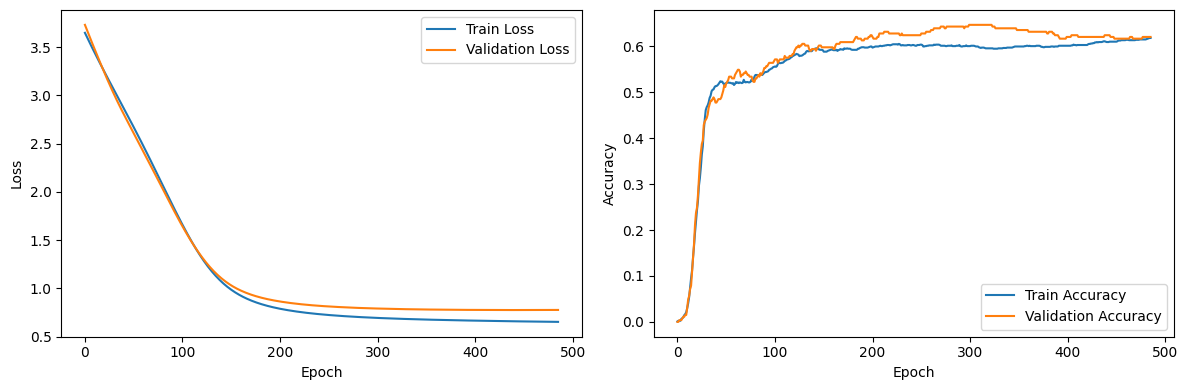


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3449, Val Loss: 3.3339, Train Acc: 0.0789, Val Acc: 0.1294
Epoch: 020, Train Loss: 3.1376, Val Loss: 3.1607, Train Acc: 0.3985, Val Acc: 0.4392
Epoch: 030, Train Loss: 2.9459, Val Loss: 2.9893, Train Acc: 0.5327, Val Acc: 0.5490
Epoch: 040, Train Loss: 2.7643, Val Loss: 2.8163, Train Acc: 0.5344, Val Acc: 0.5490
Epoch: 050, Train Loss: 2.5821, Val Loss: 2.6365, Train Acc: 0.5344, Val Acc: 0.5490
Epoch: 060, Train Loss: 2.3942, Val Loss: 2.4467, Train Acc: 0.5411, Val Acc: 0.5569
Epoch: 070, Train Loss: 2.1989, Val Loss: 2.2468, Train Acc: 0.5445, Val Acc: 0.5608
Epoch: 080, Train Loss: 1.9978, Val Loss: 2.0402, Train Acc: 0.5487, Val Acc: 0.5686
Epoch: 090, Train Loss: 1.7949, Val Loss: 1.8311, Train Acc: 0.5596, Val Acc: 0.5765
Epoch: 100, Train Loss: 1.5979, Val Loss: 1.6284, Train Acc: 0.5671, Val Acc: 0.5804
Epoch: 110, Train Loss: 1.4158, Val Loss: 1.4409, Tr

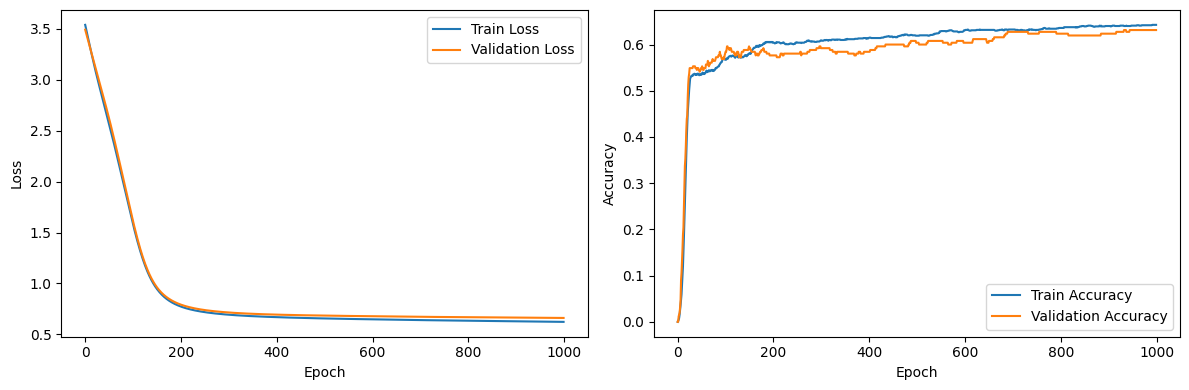


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3359, Val Loss: 3.3066, Train Acc: 0.2323, Val Acc: 0.2839
Epoch: 020, Train Loss: 3.1379, Val Loss: 3.0916, Train Acc: 0.3966, Val Acc: 0.4364
Epoch: 030, Train Loss: 2.9544, Val Loss: 2.8983, Train Acc: 0.4882, Val Acc: 0.5169
Epoch: 040, Train Loss: 2.7738, Val Loss: 2.7228, Train Acc: 0.4900, Val Acc: 0.5127
Epoch: 050, Train Loss: 2.5894, Val Loss: 2.5484, Train Acc: 0.4918, Val Acc: 0.5169
Epoch: 060, Train Loss: 2.3994, Val Loss: 2.3682, Train Acc: 0.4891, Val Acc: 0.5169
Epoch: 070, Train Loss: 2.2043, Val Loss: 2.1810, Train Acc: 0.4891, Val Acc: 0.5169
Epoch: 080, Train Loss: 2.0063, Val Loss: 1.9887, Train Acc: 0.4918, Val Acc: 0.5254
Epoch: 090, Train Loss: 1.8097, Val Loss: 1.7961, Train Acc: 0.4936, Val Acc: 0.5254
Epoch: 100, Train Loss: 1.6206, Val Loss: 1.6086, Train Acc: 0.5027, Val Acc: 0.5339
Epoch: 110, Train Loss: 1.4464, Val Loss: 1.4351, Tr

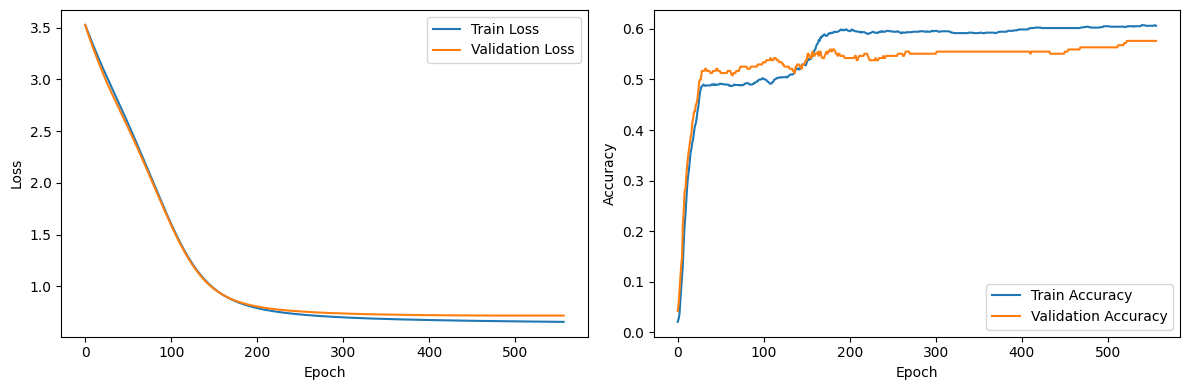


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4280, Val Loss: 3.3851, Train Acc: 0.0413, Val Acc: 0.0780
Epoch: 020, Train Loss: 3.2362, Val Loss: 3.1661, Train Acc: 0.2795, Val Acc: 0.3211
Epoch: 030, Train Loss: 3.0570, Val Loss: 2.9702, Train Acc: 0.5305, Val Acc: 0.5413
Epoch: 040, Train Loss: 2.8808, Val Loss: 2.7919, Train Acc: 0.5423, Val Acc: 0.5459
Epoch: 050, Train Loss: 2.7025, Val Loss: 2.6173, Train Acc: 0.5472, Val Acc: 0.5367
Epoch: 060, Train Loss: 2.5185, Val Loss: 2.4390, Train Acc: 0.5482, Val Acc: 0.5321
Epoch: 070, Train Loss: 2.3256, Val Loss: 2.2540, Train Acc: 0.5423, Val Acc: 0.5275
Epoch: 080, Train Loss: 2.1249, Val Loss: 2.0639, Train Acc: 0.5443, Val Acc: 0.5275
Epoch: 090, Train Loss: 1.9207, Val Loss: 1.8722, Train Acc: 0.5384, Val Acc: 0.5229
Epoch: 100, Train Loss: 1.7204, Val Loss: 1.6850, Train Acc: 0.5433, Val Acc: 0.5138
Epoch: 110, Train Loss: 1.5329, Val Loss: 1.5110, Tr

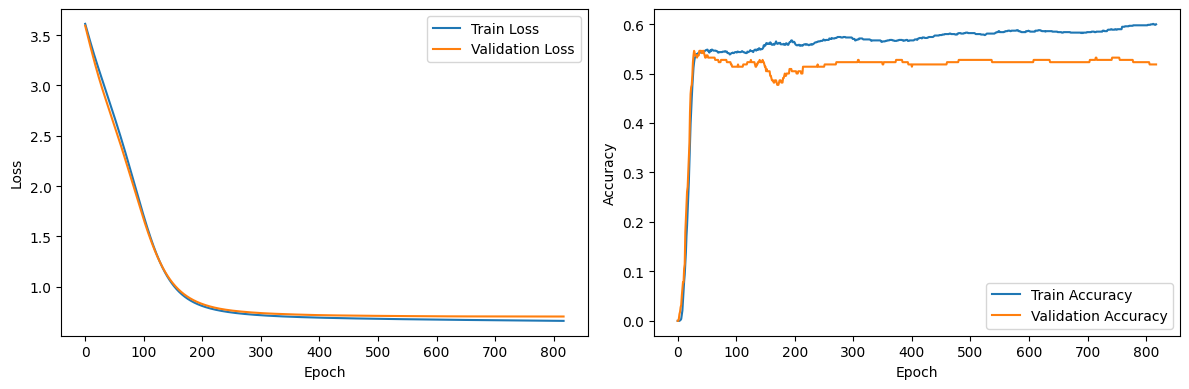


========== Run 2 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2875, Val Loss: 3.3064, Train Acc: 0.1370, Val Acc: 0.1729
Epoch: 020, Train Loss: 3.0988, Val Loss: 3.0990, Train Acc: 0.4907, Val Acc: 0.5263
Epoch: 030, Train Loss: 2.9212, Val Loss: 2.9125, Train Acc: 0.5560, Val Acc: 0.5902
Epoch: 040, Train Loss: 2.7421, Val Loss: 2.7326, Train Acc: 0.5657, Val Acc: 0.6015
Epoch: 050, Train Loss: 2.5556, Val Loss: 2.5483, Train Acc: 0.5721, Val Acc: 0.5977
Epoch: 060, Train Loss: 2.3603, Val Loss: 2.3571, Train Acc: 0.5753, Val Acc: 0.5940
Epoch: 070, Train Loss: 2.1567, Val Loss: 2.1582, Train Acc: 0.5818, Val Acc: 0.6015
Epoch: 080, Train Loss: 1.9478, Val Loss: 1.9547, Train Acc: 0.5858, Val Acc: 0.5977
Epoch: 090, Train Loss: 1.7395, Val Loss: 1.7517, Train Acc: 0.5850, Val Acc: 0.6053
Epoch: 100, Train Loss: 1.5401, Val Loss: 1.5584, Train Acc: 0.5890, Val Acc: 0.6090
Epoch: 110, Train Loss

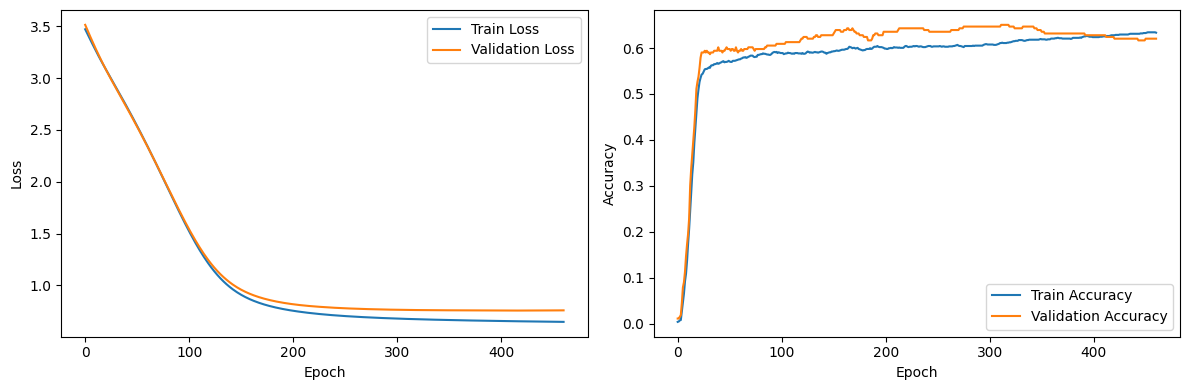


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4945, Val Loss: 3.4477, Train Acc: 0.0378, Val Acc: 0.0549
Epoch: 020, Train Loss: 3.2797, Val Loss: 3.2670, Train Acc: 0.1711, Val Acc: 0.1765
Epoch: 030, Train Loss: 3.0724, Val Loss: 3.0891, Train Acc: 0.3347, Val Acc: 0.3255
Epoch: 040, Train Loss: 2.8770, Val Loss: 2.9143, Train Acc: 0.4597, Val Acc: 0.4392
Epoch: 050, Train Loss: 2.6936, Val Loss: 2.7416, Train Acc: 0.5143, Val Acc: 0.5098
Epoch: 060, Train Loss: 2.5127, Val Loss: 2.5660, Train Acc: 0.5176, Val Acc: 0.5098
Epoch: 070, Train Loss: 2.3300, Val Loss: 2.3852, Train Acc: 0.5159, Val Acc: 0.5216
Epoch: 080, Train Loss: 2.1440, Val Loss: 2.1991, Train Acc: 0.5243, Val Acc: 0.5216
Epoch: 090, Train Loss: 1.9558, Val Loss: 2.0089, Train Acc: 0.5243, Val Acc: 0.5216
Epoch: 100, Train Loss: 1.7685, Val Loss: 1.8182, Train Acc: 0.5285, Val Acc: 0.5216
Epoch: 110, Train Loss: 1.5875, Val Loss: 1.6330, Tr

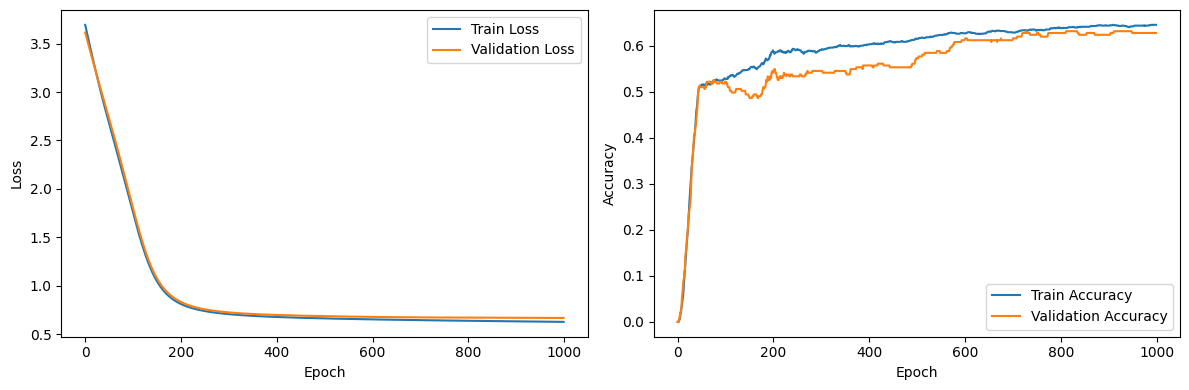


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3666, Val Loss: 3.4226, Train Acc: 0.0299, Val Acc: 0.0847
Epoch: 020, Train Loss: 3.1724, Val Loss: 3.1995, Train Acc: 0.3103, Val Acc: 0.3475
Epoch: 030, Train Loss: 2.9768, Val Loss: 2.9758, Train Acc: 0.4828, Val Acc: 0.4831
Epoch: 040, Train Loss: 2.7764, Val Loss: 2.7622, Train Acc: 0.5309, Val Acc: 0.5254
Epoch: 050, Train Loss: 2.5700, Val Loss: 2.5597, Train Acc: 0.5417, Val Acc: 0.5424
Epoch: 060, Train Loss: 2.3576, Val Loss: 2.3582, Train Acc: 0.5717, Val Acc: 0.5381
Epoch: 070, Train Loss: 2.1422, Val Loss: 2.1533, Train Acc: 0.5853, Val Acc: 0.5339
Epoch: 080, Train Loss: 1.9270, Val Loss: 1.9467, Train Acc: 0.5907, Val Acc: 0.5424
Epoch: 090, Train Loss: 1.7181, Val Loss: 1.7432, Train Acc: 0.5889, Val Acc: 0.5381
Epoch: 100, Train Loss: 1.5238, Val Loss: 1.5518, Train Acc: 0.5926, Val Acc: 0.5339
Epoch: 110, Train Loss: 1.3521, Val Loss: 1.3818, Tr

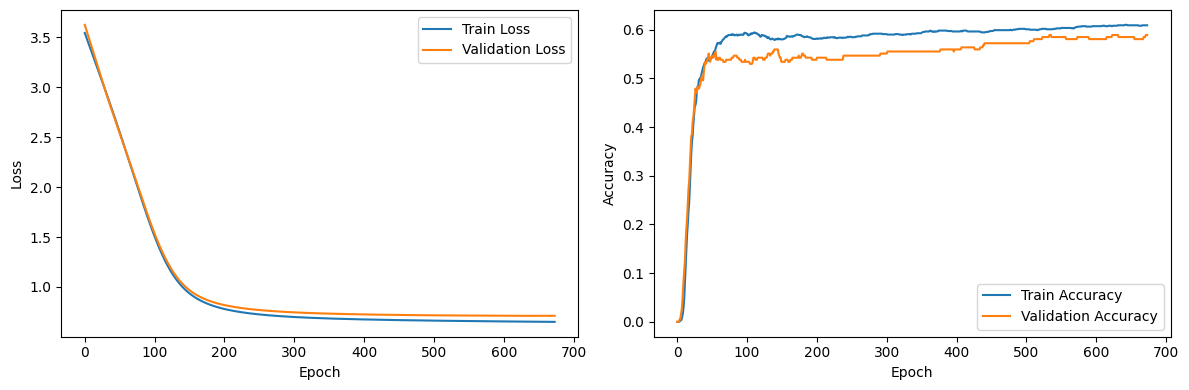


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4254, Val Loss: 3.3612, Train Acc: 0.0807, Val Acc: 0.1101
Epoch: 020, Train Loss: 3.2430, Val Loss: 3.1599, Train Acc: 0.3327, Val Acc: 0.3761
Epoch: 030, Train Loss: 3.0661, Val Loss: 2.9760, Train Acc: 0.4774, Val Acc: 0.4908
Epoch: 040, Train Loss: 2.8851, Val Loss: 2.7938, Train Acc: 0.4931, Val Acc: 0.5183
Epoch: 050, Train Loss: 2.6933, Val Loss: 2.6024, Train Acc: 0.5020, Val Acc: 0.5229
Epoch: 060, Train Loss: 2.4882, Val Loss: 2.3997, Train Acc: 0.5039, Val Acc: 0.5321
Epoch: 070, Train Loss: 2.2712, Val Loss: 2.1885, Train Acc: 0.5118, Val Acc: 0.5183
Epoch: 080, Train Loss: 2.0479, Val Loss: 1.9741, Train Acc: 0.5079, Val Acc: 0.5229
Epoch: 090, Train Loss: 1.8271, Val Loss: 1.7655, Train Acc: 0.5128, Val Acc: 0.5321
Epoch: 100, Train Loss: 1.6191, Val Loss: 1.5717, Train Acc: 0.5167, Val Acc: 0.5367
Epoch: 110, Train Loss: 1.4344, Val Loss: 1.4009, Tr

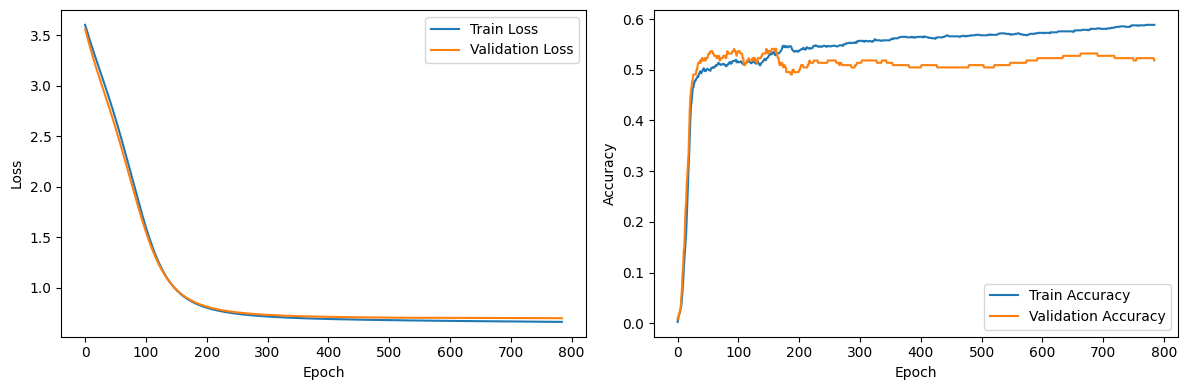


========== Run 3 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4068, Val Loss: 3.4121, Train Acc: 0.0177, Val Acc: 0.0150
Epoch: 020, Train Loss: 3.2099, Val Loss: 3.1960, Train Acc: 0.2683, Val Acc: 0.3008
Epoch: 030, Train Loss: 3.0226, Val Loss: 3.0019, Train Acc: 0.5439, Val Acc: 0.5789
Epoch: 040, Train Loss: 2.8401, Val Loss: 2.8199, Train Acc: 0.5576, Val Acc: 0.5752
Epoch: 050, Train Loss: 2.6584, Val Loss: 2.6414, Train Acc: 0.5544, Val Acc: 0.5752
Epoch: 060, Train Loss: 2.4736, Val Loss: 2.4594, Train Acc: 0.5479, Val Acc: 0.5714
Epoch: 070, Train Loss: 2.2824, Val Loss: 2.2685, Train Acc: 0.5488, Val Acc: 0.5714
Epoch: 080, Train Loss: 2.0855, Val Loss: 2.0700, Train Acc: 0.5616, Val Acc: 0.5677
Epoch: 090, Train Loss: 1.8862, Val Loss: 1.8692, Train Acc: 0.5753, Val Acc: 0.5752
Epoch: 100, Train Loss: 1.6903, Val Loss: 1.6726, Train Acc: 0.5697, Val Acc: 0.5714
Epoch: 110, Train Loss

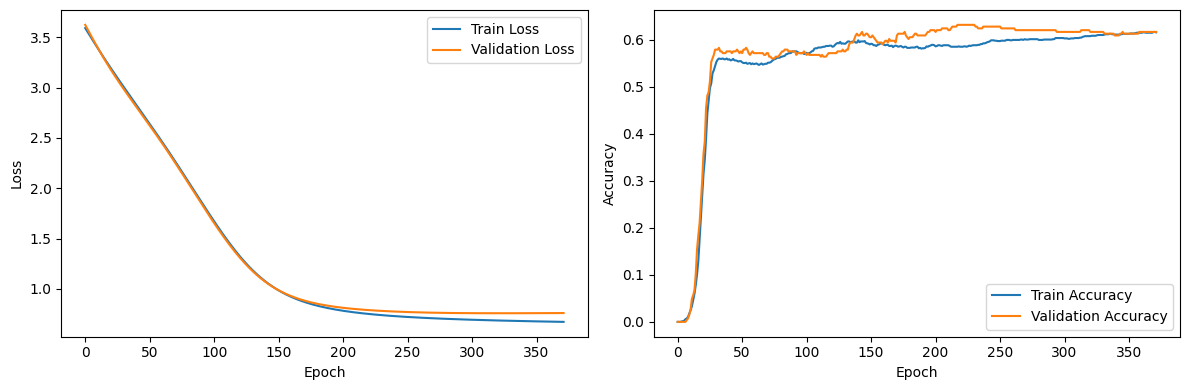


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1702, Val Loss: 3.1939, Train Acc: 0.2232, Val Acc: 0.3098
Epoch: 020, Train Loss: 2.9758, Val Loss: 3.0230, Train Acc: 0.4857, Val Acc: 0.4706
Epoch: 030, Train Loss: 2.7984, Val Loss: 2.8565, Train Acc: 0.5134, Val Acc: 0.4980
Epoch: 040, Train Loss: 2.6239, Val Loss: 2.6867, Train Acc: 0.5218, Val Acc: 0.5059
Epoch: 050, Train Loss: 2.4455, Val Loss: 2.5077, Train Acc: 0.5210, Val Acc: 0.5020
Epoch: 060, Train Loss: 2.2598, Val Loss: 2.3180, Train Acc: 0.5218, Val Acc: 0.5020
Epoch: 070, Train Loss: 2.0668, Val Loss: 2.1187, Train Acc: 0.5235, Val Acc: 0.4941
Epoch: 080, Train Loss: 1.8697, Val Loss: 1.9140, Train Acc: 0.5252, Val Acc: 0.4941
Epoch: 090, Train Loss: 1.6746, Val Loss: 1.7111, Train Acc: 0.5260, Val Acc: 0.5020
Epoch: 100, Train Loss: 1.4903, Val Loss: 1.5196, Train Acc: 0.5268, Val Acc: 0.5059
Epoch: 110, Train Loss: 1.3257, Val Loss: 1.3495, Tr

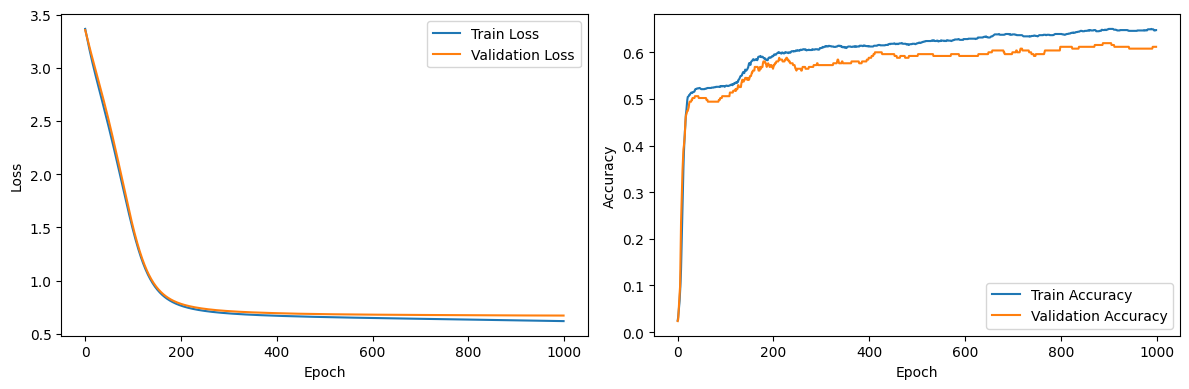


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1447, Val Loss: 3.1119, Train Acc: 0.3657, Val Acc: 0.3729
Epoch: 020, Train Loss: 2.9535, Val Loss: 2.9358, Train Acc: 0.5372, Val Acc: 0.5212
Epoch: 030, Train Loss: 2.7583, Val Loss: 2.7544, Train Acc: 0.5454, Val Acc: 0.5254
Epoch: 040, Train Loss: 2.5547, Val Loss: 2.5641, Train Acc: 0.5526, Val Acc: 0.5127
Epoch: 050, Train Loss: 2.3417, Val Loss: 2.3637, Train Acc: 0.5526, Val Acc: 0.5127
Epoch: 060, Train Loss: 2.1223, Val Loss: 2.1546, Train Acc: 0.5463, Val Acc: 0.5000
Epoch: 070, Train Loss: 1.9023, Val Loss: 1.9421, Train Acc: 0.5499, Val Acc: 0.5042
Epoch: 080, Train Loss: 1.6903, Val Loss: 1.7356, Train Acc: 0.5517, Val Acc: 0.4915
Epoch: 090, Train Loss: 1.4963, Val Loss: 1.5457, Train Acc: 0.5481, Val Acc: 0.4915
Epoch: 100, Train Loss: 1.3292, Val Loss: 1.3808, Train Acc: 0.5499, Val Acc: 0.4831
Epoch: 110, Train Loss: 1.1927, Val Loss: 1.2449, Tr

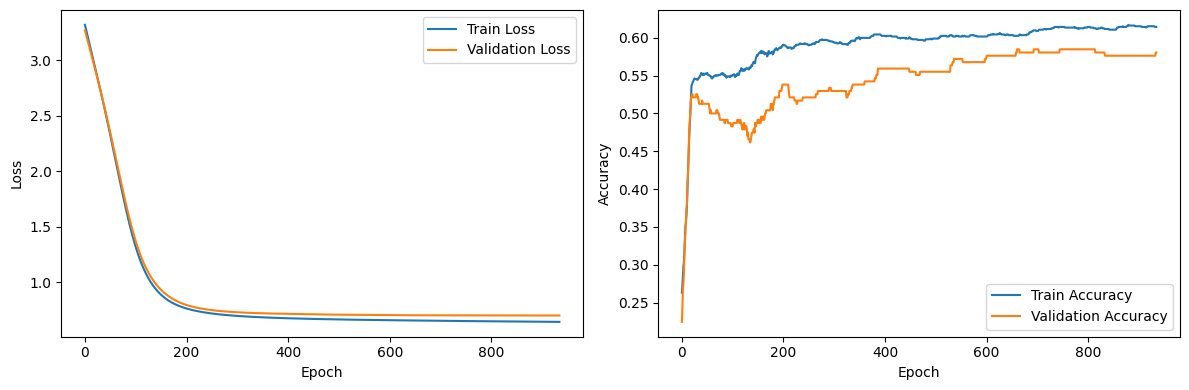


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5142, Val Loss: 3.4810, Train Acc: 0.0020, Val Acc: 0.0046
Epoch: 020, Train Loss: 3.3182, Val Loss: 3.2648, Train Acc: 0.1093, Val Acc: 0.1560
Epoch: 030, Train Loss: 3.1327, Val Loss: 3.0712, Train Acc: 0.3996, Val Acc: 0.3578
Epoch: 040, Train Loss: 2.9552, Val Loss: 2.8934, Train Acc: 0.5020, Val Acc: 0.4358
Epoch: 050, Train Loss: 2.7792, Val Loss: 2.7174, Train Acc: 0.5217, Val Acc: 0.4587
Epoch: 060, Train Loss: 2.5963, Val Loss: 2.5347, Train Acc: 0.5246, Val Acc: 0.4450
Epoch: 070, Train Loss: 2.4024, Val Loss: 2.3428, Train Acc: 0.5305, Val Acc: 0.4587
Epoch: 080, Train Loss: 2.1986, Val Loss: 2.1430, Train Acc: 0.5315, Val Acc: 0.4862
Epoch: 090, Train Loss: 1.9890, Val Loss: 1.9405, Train Acc: 0.5295, Val Acc: 0.4908
Epoch: 100, Train Loss: 1.7810, Val Loss: 1.7427, Train Acc: 0.5335, Val Acc: 0.4862
Epoch: 110, Train Loss: 1.5838, Val Loss: 1.5582, Tr

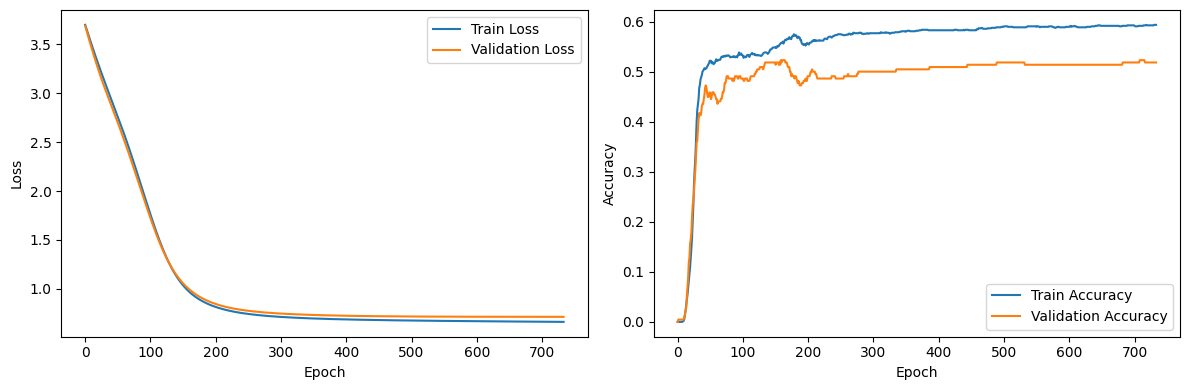


========== Run 4 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4226, Val Loss: 3.4046, Train Acc: 0.0250, Val Acc: 0.0489
Epoch: 020, Train Loss: 3.2242, Val Loss: 3.1742, Train Acc: 0.2893, Val Acc: 0.3647
Epoch: 030, Train Loss: 3.0351, Val Loss: 2.9674, Train Acc: 0.5060, Val Acc: 0.5188
Epoch: 040, Train Loss: 2.8571, Val Loss: 2.7810, Train Acc: 0.5681, Val Acc: 0.5865
Epoch: 050, Train Loss: 2.6838, Val Loss: 2.6074, Train Acc: 0.5689, Val Acc: 0.5827
Epoch: 060, Train Loss: 2.5068, Val Loss: 2.4342, Train Acc: 0.5649, Val Acc: 0.5940
Epoch: 070, Train Loss: 2.3221, Val Loss: 2.2536, Train Acc: 0.5721, Val Acc: 0.6128
Epoch: 080, Train Loss: 2.1296, Val Loss: 2.0645, Train Acc: 0.5745, Val Acc: 0.6090
Epoch: 090, Train Loss: 1.9321, Val Loss: 1.8697, Train Acc: 0.5818, Val Acc: 0.6165
Epoch: 100, Train Loss: 1.7343, Val Loss: 1.6754, Train Acc: 0.5834, Val Acc: 0.6165
Epoch: 110, Train Loss

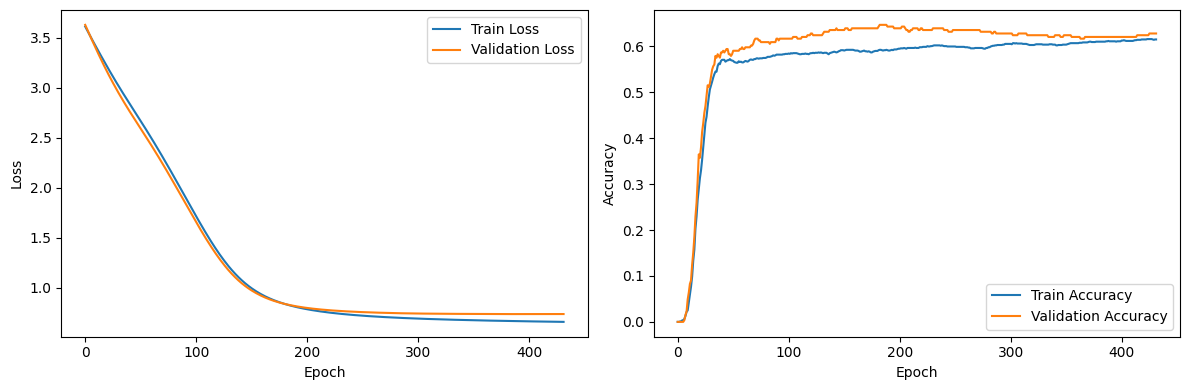


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3145, Val Loss: 3.3149, Train Acc: 0.1745, Val Acc: 0.2667
Epoch: 020, Train Loss: 3.1161, Val Loss: 3.1478, Train Acc: 0.4346, Val Acc: 0.4824
Epoch: 030, Train Loss: 2.9298, Val Loss: 2.9837, Train Acc: 0.4866, Val Acc: 0.5020
Epoch: 040, Train Loss: 2.7503, Val Loss: 2.8158, Train Acc: 0.5034, Val Acc: 0.5176
Epoch: 050, Train Loss: 2.5686, Val Loss: 2.6388, Train Acc: 0.5151, Val Acc: 0.5216
Epoch: 060, Train Loss: 2.3799, Val Loss: 2.4500, Train Acc: 0.5243, Val Acc: 0.5294
Epoch: 070, Train Loss: 2.1835, Val Loss: 2.2495, Train Acc: 0.5419, Val Acc: 0.5333
Epoch: 080, Train Loss: 1.9814, Val Loss: 2.0403, Train Acc: 0.5411, Val Acc: 0.5451
Epoch: 090, Train Loss: 1.7781, Val Loss: 1.8284, Train Acc: 0.5495, Val Acc: 0.5451
Epoch: 100, Train Loss: 1.5810, Val Loss: 1.6228, Train Acc: 0.5596, Val Acc: 0.5765
Epoch: 110, Train Loss: 1.3992, Val Loss: 1.4335, Tr

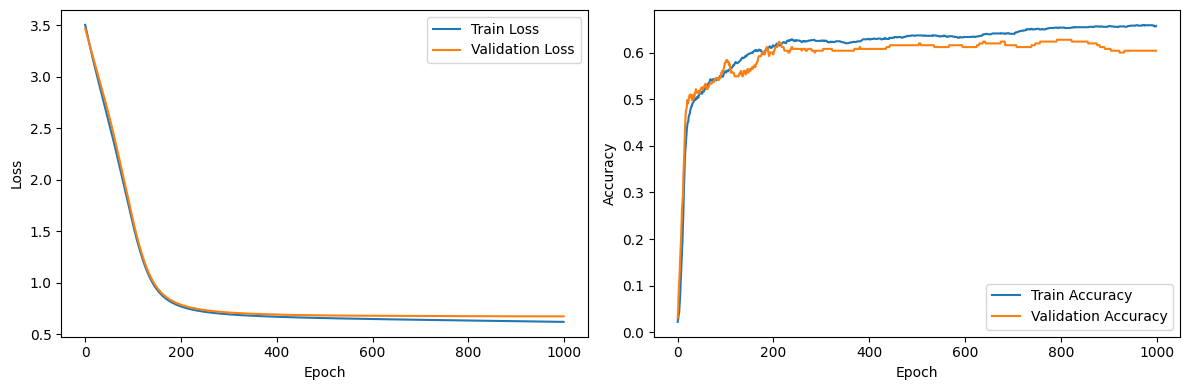


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4176, Val Loss: 3.4085, Train Acc: 0.0118, Val Acc: 0.0127
Epoch: 020, Train Loss: 3.2203, Val Loss: 3.1903, Train Acc: 0.2223, Val Acc: 0.2415
Epoch: 030, Train Loss: 3.0272, Val Loss: 2.9869, Train Acc: 0.4419, Val Acc: 0.4449
Epoch: 040, Train Loss: 2.8360, Val Loss: 2.7992, Train Acc: 0.4964, Val Acc: 0.5254
Epoch: 050, Train Loss: 2.6399, Val Loss: 2.6133, Train Acc: 0.5463, Val Acc: 0.5551
Epoch: 060, Train Loss: 2.4366, Val Loss: 2.4222, Train Acc: 0.5708, Val Acc: 0.5678
Epoch: 070, Train Loss: 2.2263, Val Loss: 2.2236, Train Acc: 0.5817, Val Acc: 0.5678
Epoch: 080, Train Loss: 2.0123, Val Loss: 2.0200, Train Acc: 0.5935, Val Acc: 0.5508
Epoch: 090, Train Loss: 1.8003, Val Loss: 1.8162, Train Acc: 0.5962, Val Acc: 0.5508
Epoch: 100, Train Loss: 1.5988, Val Loss: 1.6202, Train Acc: 0.5989, Val Acc: 0.5551
Epoch: 110, Train Loss: 1.4168, Val Loss: 1.4414, Tr

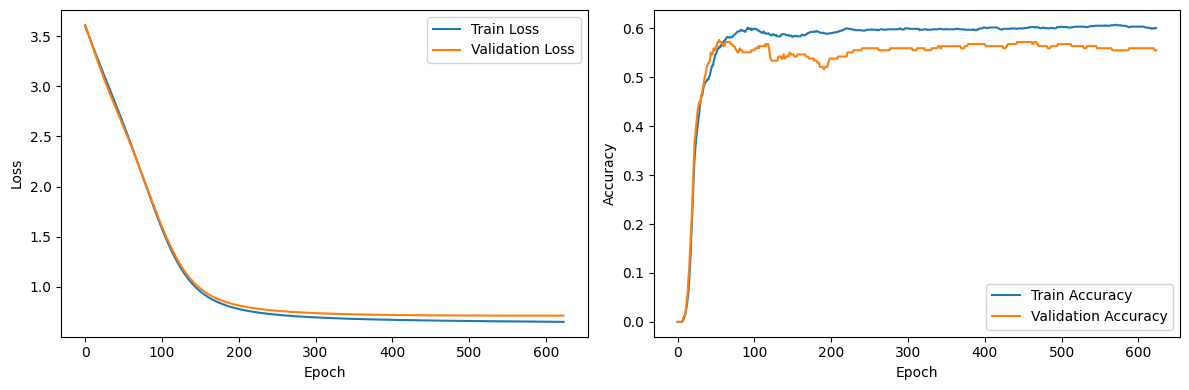


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2988, Val Loss: 3.2076, Train Acc: 0.1732, Val Acc: 0.2110
Epoch: 020, Train Loss: 3.1215, Val Loss: 3.0231, Train Acc: 0.4606, Val Acc: 0.4817
Epoch: 030, Train Loss: 2.9540, Val Loss: 2.8523, Train Acc: 0.5039, Val Acc: 0.5138
Epoch: 040, Train Loss: 2.7876, Val Loss: 2.6837, Train Acc: 0.5010, Val Acc: 0.5138
Epoch: 050, Train Loss: 2.6166, Val Loss: 2.5112, Train Acc: 0.5010, Val Acc: 0.5138
Epoch: 060, Train Loss: 2.4382, Val Loss: 2.3329, Train Acc: 0.5030, Val Acc: 0.5138
Epoch: 070, Train Loss: 2.2519, Val Loss: 2.1494, Train Acc: 0.5030, Val Acc: 0.5092
Epoch: 080, Train Loss: 2.0598, Val Loss: 1.9645, Train Acc: 0.5020, Val Acc: 0.5092
Epoch: 090, Train Loss: 1.8661, Val Loss: 1.7827, Train Acc: 0.5010, Val Acc: 0.5092
Epoch: 100, Train Loss: 1.6769, Val Loss: 1.6091, Train Acc: 0.5049, Val Acc: 0.5092
Epoch: 110, Train Loss: 1.4995, Val Loss: 1.4501, Tr

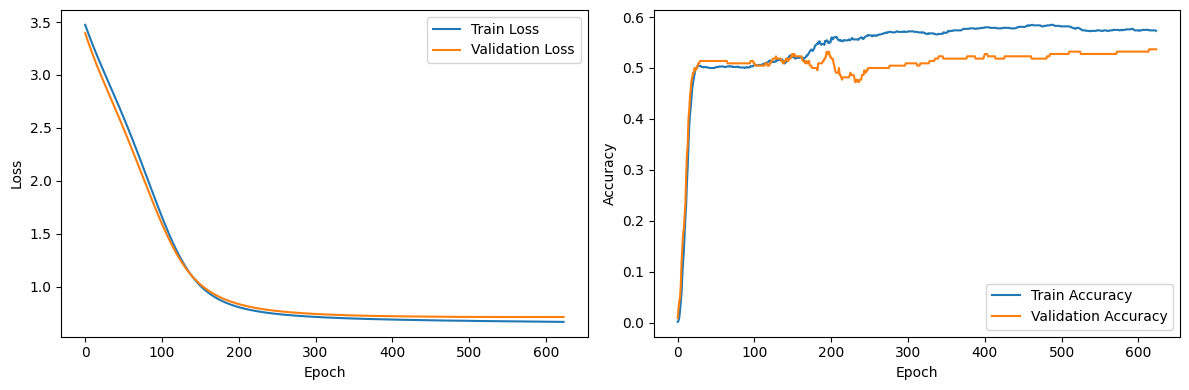


========== Run 5 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2892, Val Loss: 3.2751, Train Acc: 0.2780, Val Acc: 0.2970
Epoch: 020, Train Loss: 3.1004, Val Loss: 3.0628, Train Acc: 0.4408, Val Acc: 0.4549
Epoch: 030, Train Loss: 2.9180, Val Loss: 2.8679, Train Acc: 0.4835, Val Acc: 0.4624
Epoch: 040, Train Loss: 2.7365, Val Loss: 2.6830, Train Acc: 0.4956, Val Acc: 0.4474
Epoch: 050, Train Loss: 2.5494, Val Loss: 2.4978, Train Acc: 0.5133, Val Acc: 0.4699
Epoch: 060, Train Loss: 2.3537, Val Loss: 2.3060, Train Acc: 0.5302, Val Acc: 0.4774
Epoch: 070, Train Loss: 2.1498, Val Loss: 2.1068, Train Acc: 0.5544, Val Acc: 0.5113
Epoch: 080, Train Loss: 1.9408, Val Loss: 1.9027, Train Acc: 0.5576, Val Acc: 0.5602
Epoch: 090, Train Loss: 1.7328, Val Loss: 1.6994, Train Acc: 0.5689, Val Acc: 0.5752
Epoch: 100, Train Loss: 1.5351, Val Loss: 1.5059, Train Acc: 0.5713, Val Acc: 0.5865
Epoch: 110, Train Loss

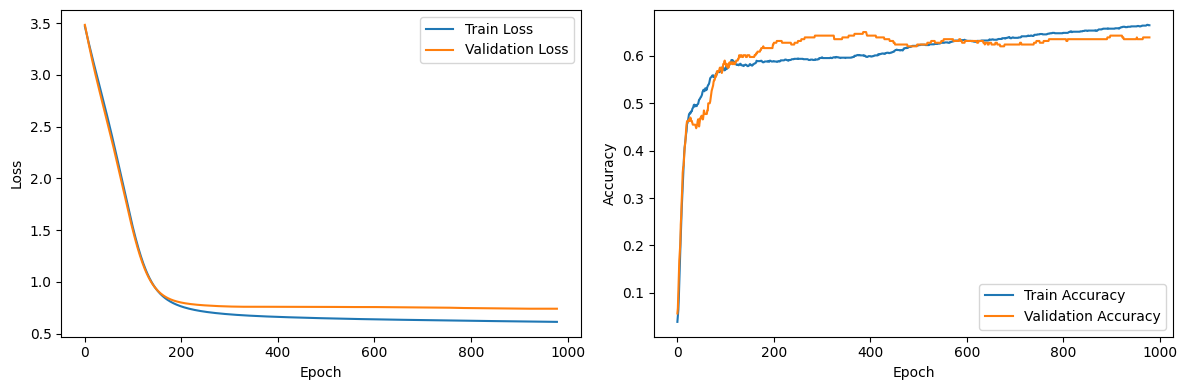


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4171, Val Loss: 3.3683, Train Acc: 0.0151, Val Acc: 0.0235
Epoch: 020, Train Loss: 3.1959, Val Loss: 3.1925, Train Acc: 0.3221, Val Acc: 0.3804
Epoch: 030, Train Loss: 2.9924, Val Loss: 3.0179, Train Acc: 0.5159, Val Acc: 0.5176
Epoch: 040, Train Loss: 2.8019, Val Loss: 2.8410, Train Acc: 0.5487, Val Acc: 0.5490
Epoch: 050, Train Loss: 2.6114, Val Loss: 2.6563, Train Acc: 0.5520, Val Acc: 0.5412
Epoch: 060, Train Loss: 2.4144, Val Loss: 2.4604, Train Acc: 0.5503, Val Acc: 0.5373
Epoch: 070, Train Loss: 2.2100, Val Loss: 2.2533, Train Acc: 0.5570, Val Acc: 0.5294
Epoch: 080, Train Loss: 2.0007, Val Loss: 2.0391, Train Acc: 0.5562, Val Acc: 0.5255
Epoch: 090, Train Loss: 1.7920, Val Loss: 1.8247, Train Acc: 0.5596, Val Acc: 0.5373
Epoch: 100, Train Loss: 1.5922, Val Loss: 1.6195, Train Acc: 0.5663, Val Acc: 0.5333
Epoch: 110, Train Loss: 1.4108, Val Loss: 1.4338, Tr

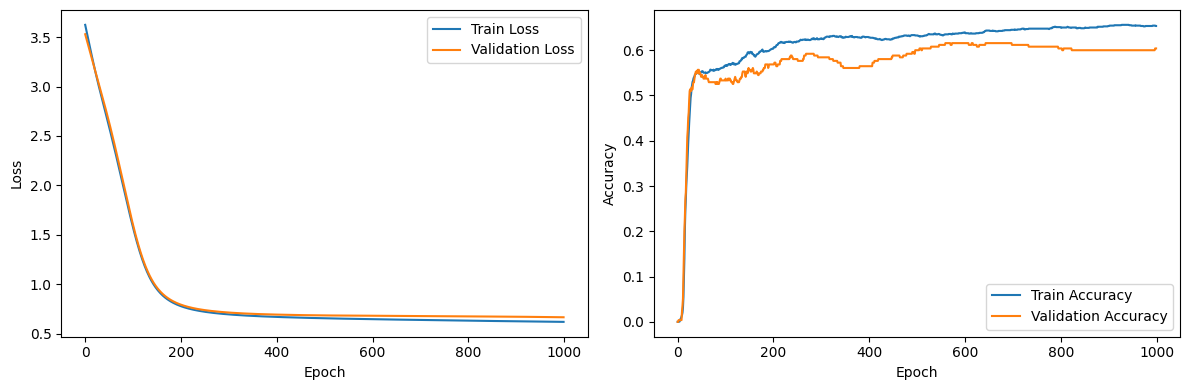


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3240, Val Loss: 3.3640, Train Acc: 0.0272, Val Acc: 0.0381
Epoch: 020, Train Loss: 3.1311, Val Loss: 3.1496, Train Acc: 0.3113, Val Acc: 0.3093
Epoch: 030, Train Loss: 2.9460, Val Loss: 2.9507, Train Acc: 0.4809, Val Acc: 0.4915
Epoch: 040, Train Loss: 2.7636, Val Loss: 2.7653, Train Acc: 0.5354, Val Acc: 0.5254
Epoch: 050, Train Loss: 2.5761, Val Loss: 2.5817, Train Acc: 0.5445, Val Acc: 0.5254
Epoch: 060, Train Loss: 2.3811, Val Loss: 2.3932, Train Acc: 0.5508, Val Acc: 0.5339
Epoch: 070, Train Loss: 2.1791, Val Loss: 2.1977, Train Acc: 0.5535, Val Acc: 0.5254
Epoch: 080, Train Loss: 1.9726, Val Loss: 1.9969, Train Acc: 0.5490, Val Acc: 0.5466
Epoch: 090, Train Loss: 1.7673, Val Loss: 1.7963, Train Acc: 0.5517, Val Acc: 0.5424
Epoch: 100, Train Loss: 1.5708, Val Loss: 1.6028, Train Acc: 0.5490, Val Acc: 0.5297
Epoch: 110, Train Loss: 1.3921, Val Loss: 1.4257, Tr

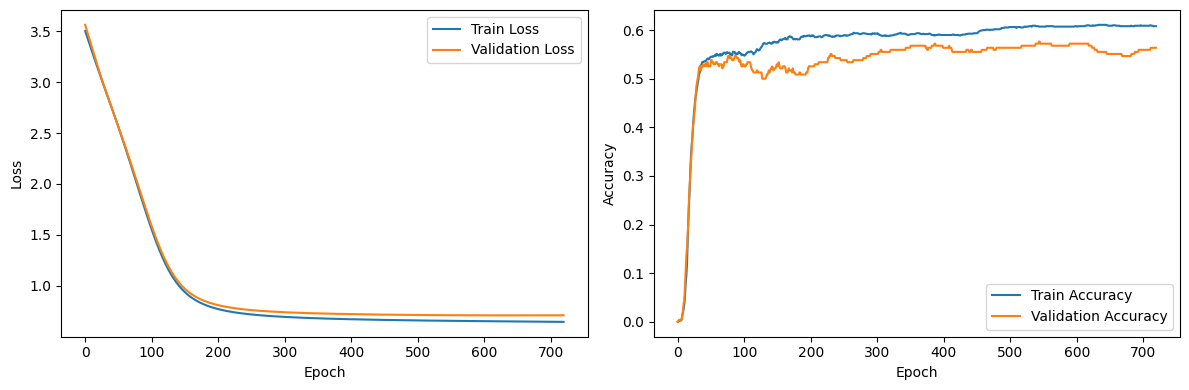


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2432, Val Loss: 3.1541, Train Acc: 0.4055, Val Acc: 0.4450
Epoch: 020, Train Loss: 3.0601, Val Loss: 2.9721, Train Acc: 0.4931, Val Acc: 0.5000
Epoch: 030, Train Loss: 2.8778, Val Loss: 2.7937, Train Acc: 0.5108, Val Acc: 0.4954
Epoch: 040, Train Loss: 2.6902, Val Loss: 2.6113, Train Acc: 0.5157, Val Acc: 0.5000
Epoch: 050, Train Loss: 2.4946, Val Loss: 2.4214, Train Acc: 0.5197, Val Acc: 0.5092
Epoch: 060, Train Loss: 2.2899, Val Loss: 2.2237, Train Acc: 0.5217, Val Acc: 0.5046
Epoch: 070, Train Loss: 2.0785, Val Loss: 2.0221, Train Acc: 0.5246, Val Acc: 0.5138
Epoch: 080, Train Loss: 1.8672, Val Loss: 1.8230, Train Acc: 0.5226, Val Acc: 0.5092
Epoch: 090, Train Loss: 1.6649, Val Loss: 1.6344, Train Acc: 0.5217, Val Acc: 0.5138
Epoch: 100, Train Loss: 1.4815, Val Loss: 1.4649, Train Acc: 0.5236, Val Acc: 0.5183
Epoch: 110, Train Loss: 1.3245, Val Loss: 1.3201, Tr

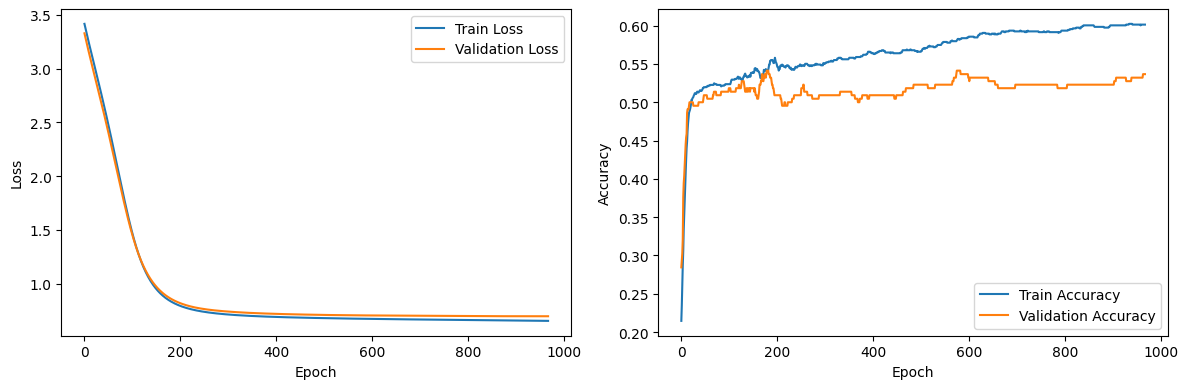


========== Run 6 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4940, Val Loss: 3.5271, Train Acc: 0.0000, Val Acc: 0.0000
Epoch: 020, Train Loss: 3.2879, Val Loss: 3.2918, Train Acc: 0.1829, Val Acc: 0.2444
Epoch: 030, Train Loss: 3.0847, Val Loss: 3.0697, Train Acc: 0.4633, Val Acc: 0.5038
Epoch: 040, Train Loss: 2.8822, Val Loss: 2.8608, Train Acc: 0.5431, Val Acc: 0.5639
Epoch: 050, Train Loss: 2.6787, Val Loss: 2.6579, Train Acc: 0.5544, Val Acc: 0.5677
Epoch: 060, Train Loss: 2.4711, Val Loss: 2.4544, Train Acc: 0.5520, Val Acc: 0.5714
Epoch: 070, Train Loss: 2.2574, Val Loss: 2.2459, Train Acc: 0.5568, Val Acc: 0.5752
Epoch: 080, Train Loss: 2.0399, Val Loss: 2.0344, Train Acc: 0.5552, Val Acc: 0.5827
Epoch: 090, Train Loss: 1.8242, Val Loss: 1.8249, Train Acc: 0.5600, Val Acc: 0.5752
Epoch: 100, Train Loss: 1.6189, Val Loss: 1.6263, Train Acc: 0.5616, Val Acc: 0.5752
Epoch: 110, Train Loss

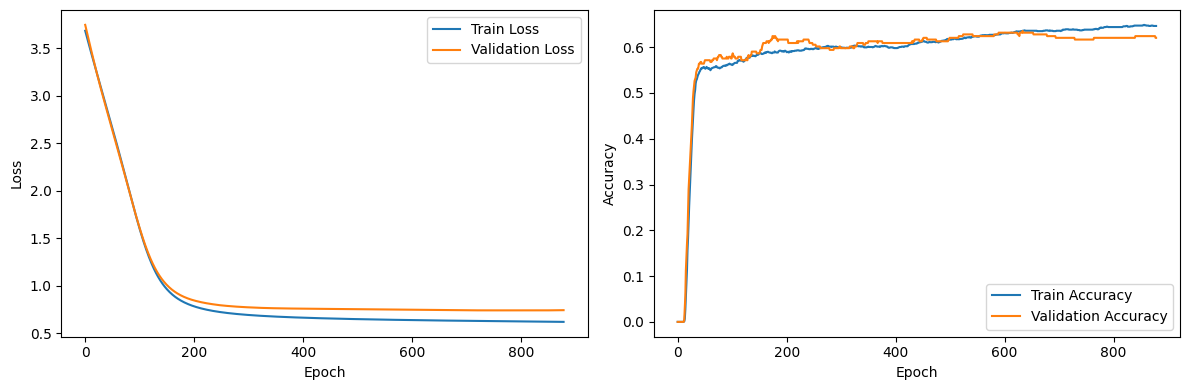


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3378, Val Loss: 3.3394, Train Acc: 0.1233, Val Acc: 0.1294
Epoch: 020, Train Loss: 3.1294, Val Loss: 3.1551, Train Acc: 0.3389, Val Acc: 0.3529
Epoch: 030, Train Loss: 2.9279, Val Loss: 2.9724, Train Acc: 0.4958, Val Acc: 0.4784
Epoch: 040, Train Loss: 2.7318, Val Loss: 2.7866, Train Acc: 0.5344, Val Acc: 0.4902
Epoch: 050, Train Loss: 2.5349, Val Loss: 2.5935, Train Acc: 0.5394, Val Acc: 0.5020
Epoch: 060, Train Loss: 2.3332, Val Loss: 2.3913, Train Acc: 0.5411, Val Acc: 0.5059
Epoch: 070, Train Loss: 2.1265, Val Loss: 2.1810, Train Acc: 0.5403, Val Acc: 0.5059
Epoch: 080, Train Loss: 1.9179, Val Loss: 1.9675, Train Acc: 0.5419, Val Acc: 0.5059
Epoch: 090, Train Loss: 1.7139, Val Loss: 1.7581, Train Acc: 0.5453, Val Acc: 0.5098
Epoch: 100, Train Loss: 1.5231, Val Loss: 1.5626, Train Acc: 0.5478, Val Acc: 0.5098
Epoch: 110, Train Loss: 1.3542, Val Loss: 1.3903, Tr

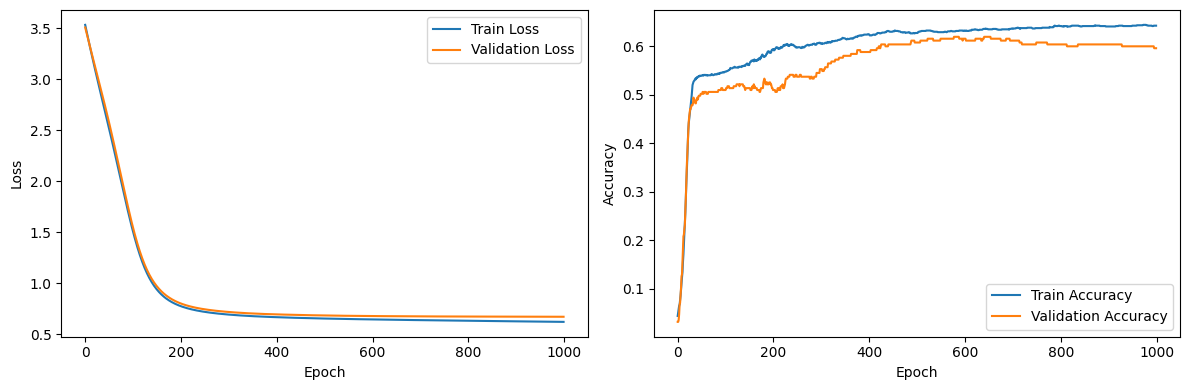


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2659, Val Loss: 3.3430, Train Acc: 0.2196, Val Acc: 0.2458
Epoch: 020, Train Loss: 3.0785, Val Loss: 3.1112, Train Acc: 0.3612, Val Acc: 0.3941
Epoch: 030, Train Loss: 2.8955, Val Loss: 2.8933, Train Acc: 0.5091, Val Acc: 0.5042
Epoch: 040, Train Loss: 2.7115, Val Loss: 2.6875, Train Acc: 0.5699, Val Acc: 0.5466
Epoch: 050, Train Loss: 2.5224, Val Loss: 2.4873, Train Acc: 0.5789, Val Acc: 0.5636
Epoch: 060, Train Loss: 2.3267, Val Loss: 2.2851, Train Acc: 0.5753, Val Acc: 0.5551
Epoch: 070, Train Loss: 2.1246, Val Loss: 2.0809, Train Acc: 0.5753, Val Acc: 0.5551
Epoch: 080, Train Loss: 1.9190, Val Loss: 1.8755, Train Acc: 0.5808, Val Acc: 0.5593
Epoch: 090, Train Loss: 1.7153, Val Loss: 1.6740, Train Acc: 0.5826, Val Acc: 0.5466
Epoch: 100, Train Loss: 1.5215, Val Loss: 1.4842, Train Acc: 0.5808, Val Acc: 0.5593
Epoch: 110, Train Loss: 1.3467, Val Loss: 1.3154, Tr

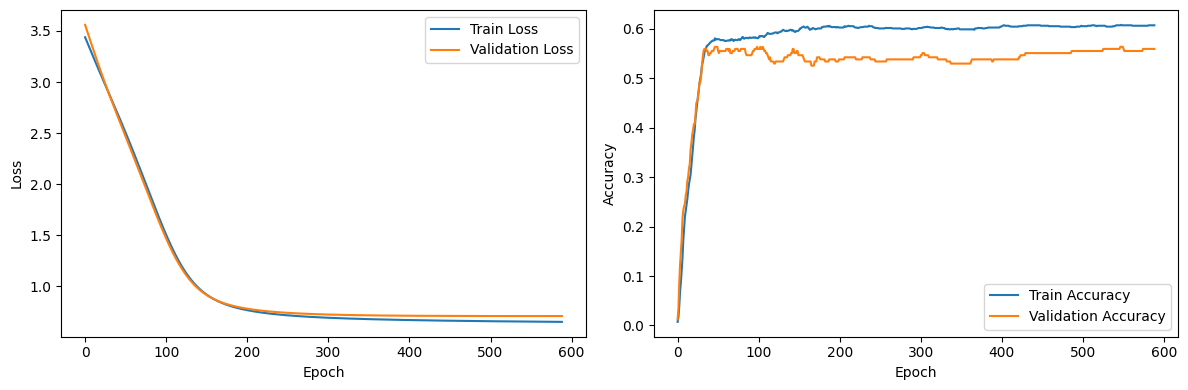


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4198, Val Loss: 3.4123, Train Acc: 0.1663, Val Acc: 0.1789
Epoch: 020, Train Loss: 3.2195, Val Loss: 3.2077, Train Acc: 0.3346, Val Acc: 0.3532
Epoch: 030, Train Loss: 3.0310, Val Loss: 3.0184, Train Acc: 0.5315, Val Acc: 0.4725
Epoch: 040, Train Loss: 2.8464, Val Loss: 2.8311, Train Acc: 0.5463, Val Acc: 0.4771
Epoch: 050, Train Loss: 2.6587, Val Loss: 2.6408, Train Acc: 0.5502, Val Acc: 0.4817
Epoch: 060, Train Loss: 2.4652, Val Loss: 2.4455, Train Acc: 0.5502, Val Acc: 0.4817
Epoch: 070, Train Loss: 2.2655, Val Loss: 2.2455, Train Acc: 0.5472, Val Acc: 0.4771
Epoch: 080, Train Loss: 2.0620, Val Loss: 2.0440, Train Acc: 0.5492, Val Acc: 0.4771
Epoch: 090, Train Loss: 1.8595, Val Loss: 1.8464, Train Acc: 0.5463, Val Acc: 0.4817
Epoch: 100, Train Loss: 1.6647, Val Loss: 1.6590, Train Acc: 0.5482, Val Acc: 0.4771
Epoch: 110, Train Loss: 1.4852, Val Loss: 1.4884, Tr

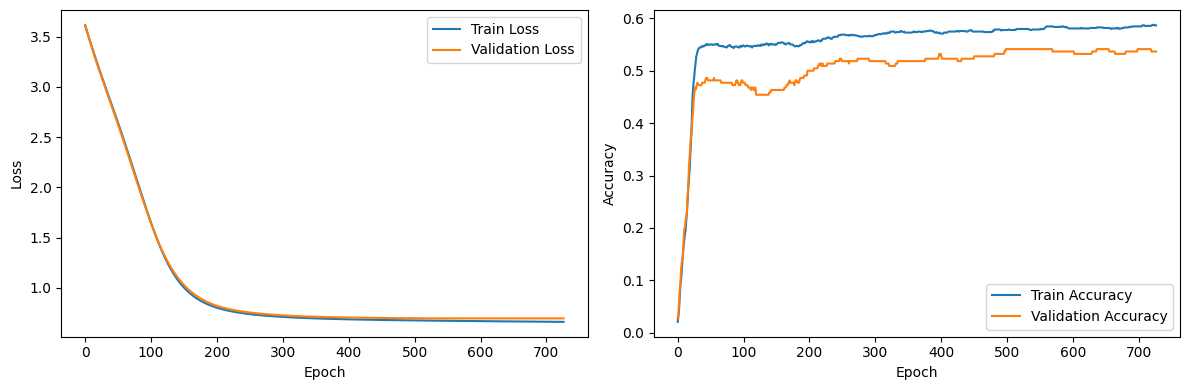


========== Run 7 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5421, Val Loss: 3.5646, Train Acc: 0.0766, Val Acc: 0.1241
Epoch: 020, Train Loss: 3.3308, Val Loss: 3.3225, Train Acc: 0.3433, Val Acc: 0.3271
Epoch: 030, Train Loss: 3.1286, Val Loss: 3.1046, Train Acc: 0.4770, Val Acc: 0.4774
Epoch: 040, Train Loss: 2.9330, Val Loss: 2.9038, Train Acc: 0.5004, Val Acc: 0.4925
Epoch: 050, Train Loss: 2.7378, Val Loss: 2.7085, Train Acc: 0.5101, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.5403, Val Loss: 2.5136, Train Acc: 0.5109, Val Acc: 0.4925
Epoch: 070, Train Loss: 2.3404, Val Loss: 2.3188, Train Acc: 0.5125, Val Acc: 0.4962
Epoch: 080, Train Loss: 2.1401, Val Loss: 2.1262, Train Acc: 0.5165, Val Acc: 0.4925
Epoch: 090, Train Loss: 1.9423, Val Loss: 1.9338, Train Acc: 0.5189, Val Acc: 0.4925
Epoch: 100, Train Loss: 1.7505, Val Loss: 1.7437, Train Acc: 0.5214, Val Acc: 0.5000
Epoch: 110, Train Loss

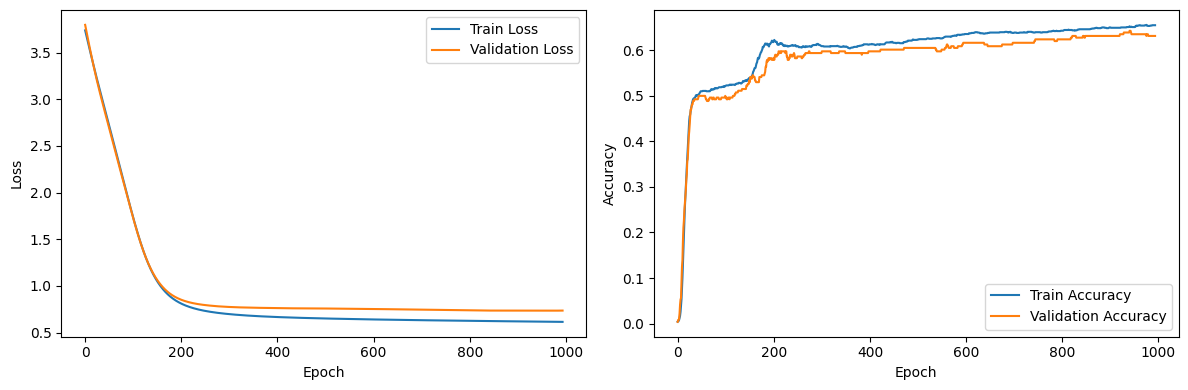


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3810, Val Loss: 3.3864, Train Acc: 0.0956, Val Acc: 0.0902
Epoch: 020, Train Loss: 3.1849, Val Loss: 3.2196, Train Acc: 0.3775, Val Acc: 0.3882
Epoch: 030, Train Loss: 2.9985, Val Loss: 3.0525, Train Acc: 0.4832, Val Acc: 0.4667
Epoch: 040, Train Loss: 2.8150, Val Loss: 2.8806, Train Acc: 0.5151, Val Acc: 0.4902
Epoch: 050, Train Loss: 2.6300, Val Loss: 2.6995, Train Acc: 0.5243, Val Acc: 0.5059
Epoch: 060, Train Loss: 2.4367, Val Loss: 2.5053, Train Acc: 0.5260, Val Acc: 0.5176
Epoch: 070, Train Loss: 2.2329, Val Loss: 2.2976, Train Acc: 0.5378, Val Acc: 0.5059
Epoch: 080, Train Loss: 2.0219, Val Loss: 2.0810, Train Acc: 0.5461, Val Acc: 0.5020
Epoch: 090, Train Loss: 1.8106, Val Loss: 1.8638, Train Acc: 0.5487, Val Acc: 0.4980
Epoch: 100, Train Loss: 1.6085, Val Loss: 1.6565, Train Acc: 0.5470, Val Acc: 0.4941
Epoch: 110, Train Loss: 1.4257, Val Loss: 1.4696, Tr

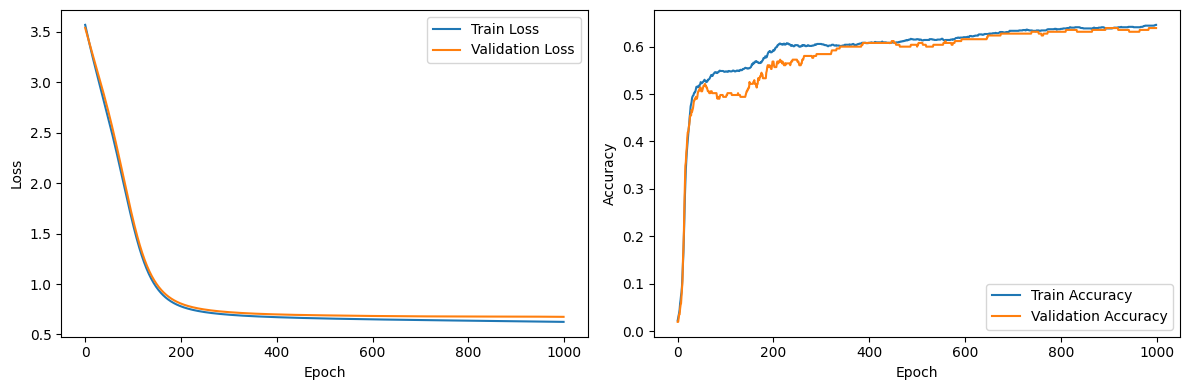


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4267, Val Loss: 3.4236, Train Acc: 0.0073, Val Acc: 0.0212
Epoch: 020, Train Loss: 3.2364, Val Loss: 3.2012, Train Acc: 0.2559, Val Acc: 0.3432
Epoch: 030, Train Loss: 3.0538, Val Loss: 3.0056, Train Acc: 0.4537, Val Acc: 0.4492
Epoch: 040, Train Loss: 2.8743, Val Loss: 2.8334, Train Acc: 0.5064, Val Acc: 0.4958
Epoch: 050, Train Loss: 2.6929, Val Loss: 2.6584, Train Acc: 0.5181, Val Acc: 0.5169
Epoch: 060, Train Loss: 2.5049, Val Loss: 2.4753, Train Acc: 0.5172, Val Acc: 0.5169
Epoch: 070, Train Loss: 2.3085, Val Loss: 2.2837, Train Acc: 0.5200, Val Acc: 0.5212
Epoch: 080, Train Loss: 2.1055, Val Loss: 2.0850, Train Acc: 0.5191, Val Acc: 0.5254
Epoch: 090, Train Loss: 1.8998, Val Loss: 1.8842, Train Acc: 0.5209, Val Acc: 0.5212
Epoch: 100, Train Loss: 1.6983, Val Loss: 1.6879, Train Acc: 0.5254, Val Acc: 0.5169
Epoch: 110, Train Loss: 1.5097, Val Loss: 1.5045, Tr

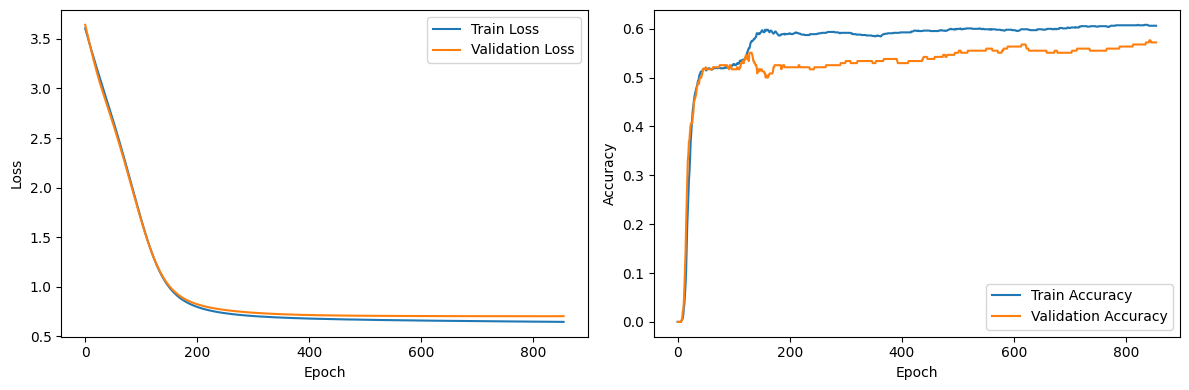


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2616, Val Loss: 3.1855, Train Acc: 0.2175, Val Acc: 0.2523
Epoch: 020, Train Loss: 3.0730, Val Loss: 2.9934, Train Acc: 0.4823, Val Acc: 0.4771
Epoch: 030, Train Loss: 2.8875, Val Loss: 2.8055, Train Acc: 0.5128, Val Acc: 0.5092
Epoch: 040, Train Loss: 2.6964, Val Loss: 2.6158, Train Acc: 0.5217, Val Acc: 0.4954
Epoch: 050, Train Loss: 2.4964, Val Loss: 2.4200, Train Acc: 0.5167, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.2878, Val Loss: 2.2177, Train Acc: 0.5148, Val Acc: 0.4817
Epoch: 070, Train Loss: 2.0724, Val Loss: 2.0116, Train Acc: 0.5167, Val Acc: 0.5046
Epoch: 080, Train Loss: 1.8560, Val Loss: 1.8082, Train Acc: 0.5207, Val Acc: 0.5138
Epoch: 090, Train Loss: 1.6478, Val Loss: 1.6154, Train Acc: 0.5148, Val Acc: 0.5183
Epoch: 100, Train Loss: 1.4584, Val Loss: 1.4423, Train Acc: 0.5148, Val Acc: 0.5183
Epoch: 110, Train Loss: 1.2966, Val Loss: 1.2953, Tr

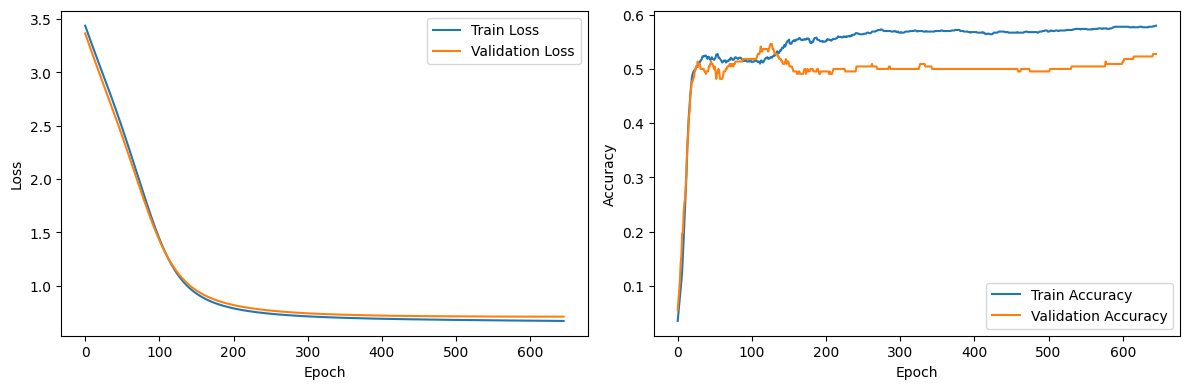


========== Run 8 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3704, Val Loss: 3.3753, Train Acc: 0.1781, Val Acc: 0.1692
Epoch: 020, Train Loss: 3.1797, Val Loss: 3.1608, Train Acc: 0.4279, Val Acc: 0.4211
Epoch: 030, Train Loss: 3.0015, Val Loss: 2.9754, Train Acc: 0.4980, Val Acc: 0.4850
Epoch: 040, Train Loss: 2.8273, Val Loss: 2.8067, Train Acc: 0.5068, Val Acc: 0.4812
Epoch: 050, Train Loss: 2.6491, Val Loss: 2.6372, Train Acc: 0.5044, Val Acc: 0.4887
Epoch: 060, Train Loss: 2.4629, Val Loss: 2.4589, Train Acc: 0.5093, Val Acc: 0.4812
Epoch: 070, Train Loss: 2.2680, Val Loss: 2.2714, Train Acc: 0.5125, Val Acc: 0.5038
Epoch: 080, Train Loss: 2.0667, Val Loss: 2.0764, Train Acc: 0.5149, Val Acc: 0.4962
Epoch: 090, Train Loss: 1.8634, Val Loss: 1.8784, Train Acc: 0.5157, Val Acc: 0.4774
Epoch: 100, Train Loss: 1.6647, Val Loss: 1.6838, Train Acc: 0.5157, Val Acc: 0.4774
Epoch: 110, Train Loss

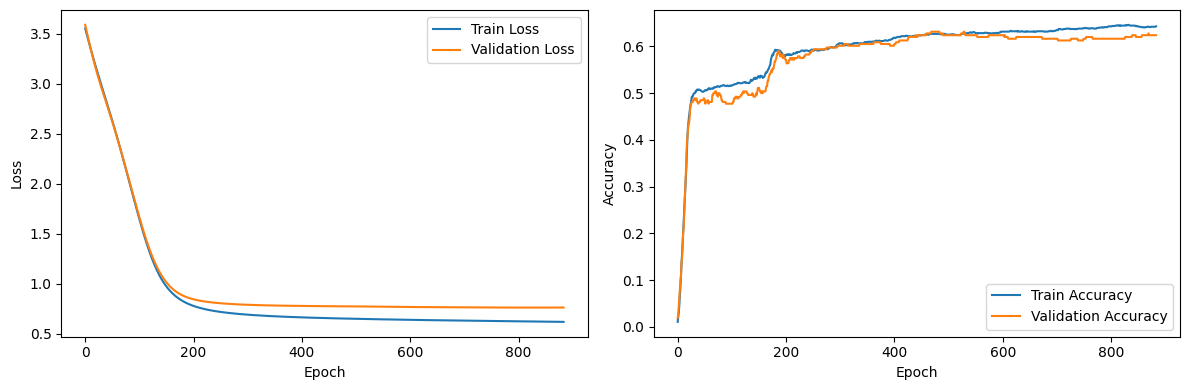


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2833, Val Loss: 3.2761, Train Acc: 0.2013, Val Acc: 0.2118
Epoch: 020, Train Loss: 3.0883, Val Loss: 3.1102, Train Acc: 0.3473, Val Acc: 0.3373
Epoch: 030, Train Loss: 2.9051, Val Loss: 2.9474, Train Acc: 0.4723, Val Acc: 0.4706
Epoch: 040, Train Loss: 2.7255, Val Loss: 2.7823, Train Acc: 0.5084, Val Acc: 0.5098
Epoch: 050, Train Loss: 2.5441, Val Loss: 2.6102, Train Acc: 0.5394, Val Acc: 0.5137
Epoch: 060, Train Loss: 2.3582, Val Loss: 2.4277, Train Acc: 0.5445, Val Acc: 0.5098
Epoch: 070, Train Loss: 2.1663, Val Loss: 2.2348, Train Acc: 0.5478, Val Acc: 0.5098
Epoch: 080, Train Loss: 1.9693, Val Loss: 2.0340, Train Acc: 0.5520, Val Acc: 0.5020
Epoch: 090, Train Loss: 1.7711, Val Loss: 1.8304, Train Acc: 0.5554, Val Acc: 0.5137
Epoch: 100, Train Loss: 1.5782, Val Loss: 1.6310, Train Acc: 0.5503, Val Acc: 0.5137
Epoch: 110, Train Loss: 1.3995, Val Loss: 1.4462, Tr

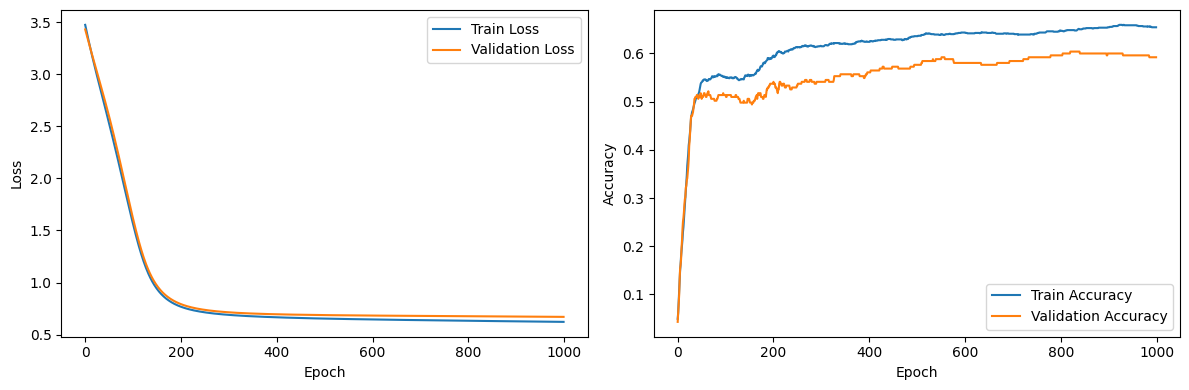


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3351, Val Loss: 3.4348, Train Acc: 0.1996, Val Acc: 0.1483
Epoch: 020, Train Loss: 3.1507, Val Loss: 3.2255, Train Acc: 0.4610, Val Acc: 0.3983
Epoch: 030, Train Loss: 2.9710, Val Loss: 3.0277, Train Acc: 0.5481, Val Acc: 0.4873
Epoch: 040, Train Loss: 2.7891, Val Loss: 2.8342, Train Acc: 0.5735, Val Acc: 0.5000
Epoch: 050, Train Loss: 2.5996, Val Loss: 2.6352, Train Acc: 0.5771, Val Acc: 0.5212
Epoch: 060, Train Loss: 2.4000, Val Loss: 2.4297, Train Acc: 0.5817, Val Acc: 0.5339
Epoch: 070, Train Loss: 2.1914, Val Loss: 2.2199, Train Acc: 0.5826, Val Acc: 0.5466
Epoch: 080, Train Loss: 1.9778, Val Loss: 2.0092, Train Acc: 0.5853, Val Acc: 0.5297
Epoch: 090, Train Loss: 1.7662, Val Loss: 1.8011, Train Acc: 0.5835, Val Acc: 0.5424
Epoch: 100, Train Loss: 1.5656, Val Loss: 1.6030, Train Acc: 0.5826, Val Acc: 0.5466
Epoch: 110, Train Loss: 1.3851, Val Loss: 1.4240, Tr

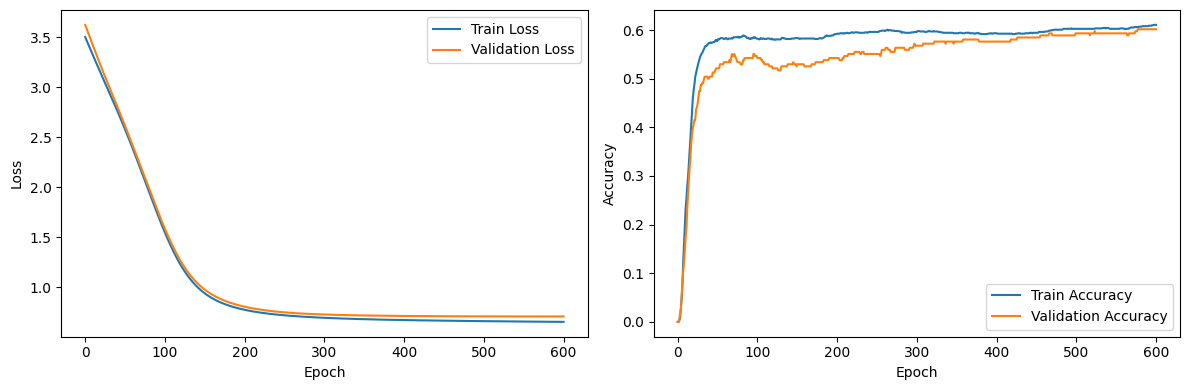


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3585, Val Loss: 3.3785, Train Acc: 0.0935, Val Acc: 0.0963
Epoch: 020, Train Loss: 3.1690, Val Loss: 3.1535, Train Acc: 0.3917, Val Acc: 0.3578
Epoch: 030, Train Loss: 2.9878, Val Loss: 2.9442, Train Acc: 0.5177, Val Acc: 0.4771
Epoch: 040, Train Loss: 2.8066, Val Loss: 2.7550, Train Acc: 0.5285, Val Acc: 0.4908
Epoch: 050, Train Loss: 2.6214, Val Loss: 2.5729, Train Acc: 0.5276, Val Acc: 0.4817
Epoch: 060, Train Loss: 2.4295, Val Loss: 2.3865, Train Acc: 0.5305, Val Acc: 0.5092
Epoch: 070, Train Loss: 2.2303, Val Loss: 2.1939, Train Acc: 0.5315, Val Acc: 0.5092
Epoch: 080, Train Loss: 2.0267, Val Loss: 1.9981, Train Acc: 0.5325, Val Acc: 0.5138
Epoch: 090, Train Loss: 1.8242, Val Loss: 1.8046, Train Acc: 0.5443, Val Acc: 0.5138
Epoch: 100, Train Loss: 1.6306, Val Loss: 1.6203, Train Acc: 0.5443, Val Acc: 0.5183
Epoch: 110, Train Loss: 1.4539, Val Loss: 1.4531, Tr

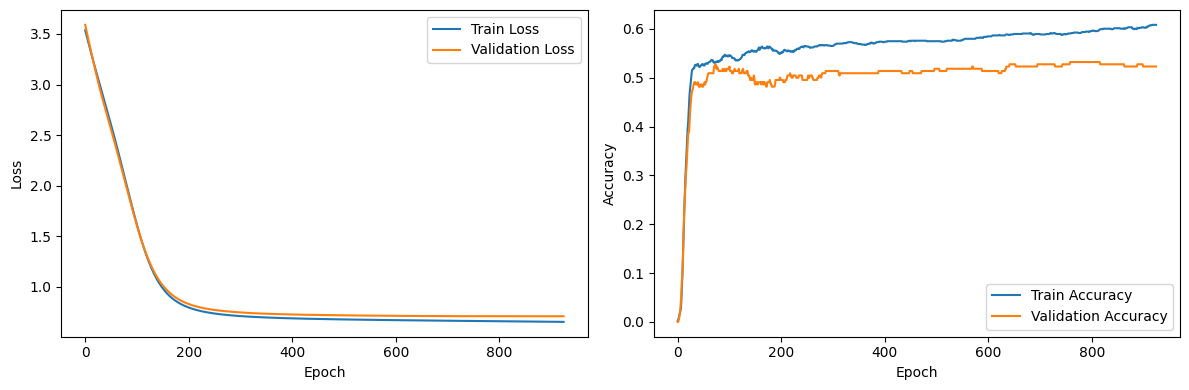


========== Run 9 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2799, Val Loss: 3.2290, Train Acc: 0.2015, Val Acc: 0.2707
Epoch: 020, Train Loss: 3.0822, Val Loss: 3.0196, Train Acc: 0.4625, Val Acc: 0.5150
Epoch: 030, Train Loss: 2.8942, Val Loss: 2.8261, Train Acc: 0.5270, Val Acc: 0.5639
Epoch: 040, Train Loss: 2.7057, Val Loss: 2.6389, Train Acc: 0.5415, Val Acc: 0.5789
Epoch: 050, Train Loss: 2.5090, Val Loss: 2.4481, Train Acc: 0.5576, Val Acc: 0.5940
Epoch: 060, Train Loss: 2.3021, Val Loss: 2.2488, Train Acc: 0.5745, Val Acc: 0.5865
Epoch: 070, Train Loss: 2.0869, Val Loss: 2.0417, Train Acc: 0.5794, Val Acc: 0.5865
Epoch: 080, Train Loss: 1.8686, Val Loss: 1.8318, Train Acc: 0.5778, Val Acc: 0.5865
Epoch: 090, Train Loss: 1.6560, Val Loss: 1.6279, Train Acc: 0.5826, Val Acc: 0.6015
Epoch: 100, Train Loss: 1.4597, Val Loss: 1.4407, Train Acc: 0.5842, Val Acc: 0.6090
Epoch: 110, Train Loss

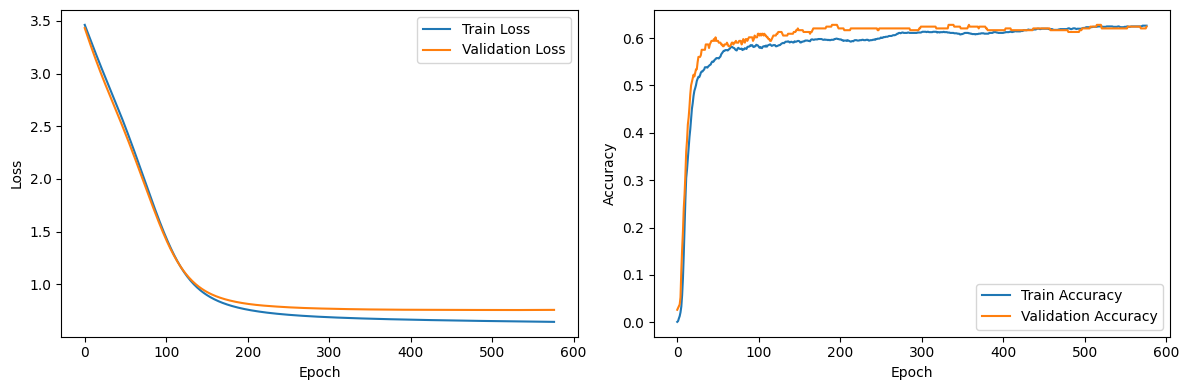


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5121, Val Loss: 3.4756, Train Acc: 0.0235, Val Acc: 0.0392
Epoch: 020, Train Loss: 3.3003, Val Loss: 3.2944, Train Acc: 0.1653, Val Acc: 0.1843
Epoch: 030, Train Loss: 3.0987, Val Loss: 3.1162, Train Acc: 0.4379, Val Acc: 0.4196
Epoch: 040, Train Loss: 2.9044, Val Loss: 2.9382, Train Acc: 0.4924, Val Acc: 0.4784
Epoch: 050, Train Loss: 2.7126, Val Loss: 2.7567, Train Acc: 0.5478, Val Acc: 0.4980
Epoch: 060, Train Loss: 2.5174, Val Loss: 2.5675, Train Acc: 0.5621, Val Acc: 0.5137
Epoch: 070, Train Loss: 2.3162, Val Loss: 2.3688, Train Acc: 0.5621, Val Acc: 0.5137
Epoch: 080, Train Loss: 2.1100, Val Loss: 2.1621, Train Acc: 0.5654, Val Acc: 0.5137
Epoch: 090, Train Loss: 1.9023, Val Loss: 1.9513, Train Acc: 0.5705, Val Acc: 0.5137
Epoch: 100, Train Loss: 1.6992, Val Loss: 1.7434, Train Acc: 0.5696, Val Acc: 0.5137
Epoch: 110, Train Loss: 1.5088, Val Loss: 1.5475, Tr

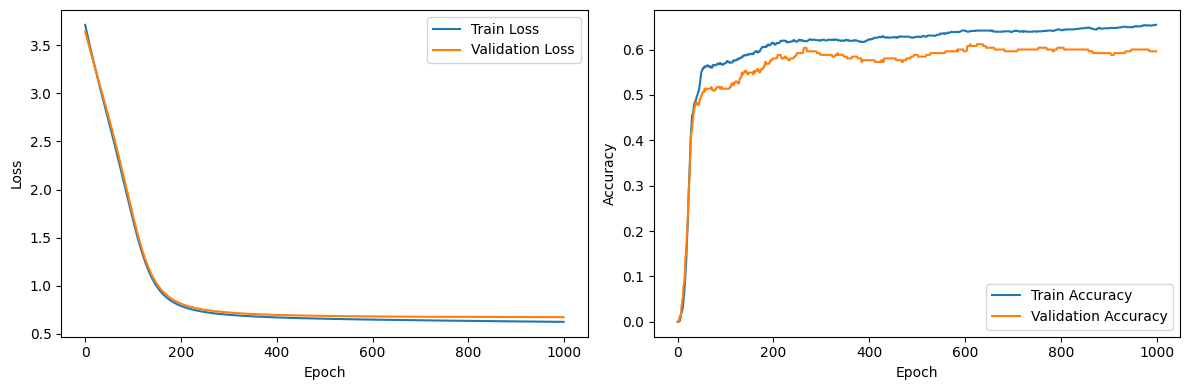


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2415, Val Loss: 3.3033, Train Acc: 0.2250, Val Acc: 0.2415
Epoch: 020, Train Loss: 3.0467, Val Loss: 3.0816, Train Acc: 0.4528, Val Acc: 0.4619
Epoch: 030, Train Loss: 2.8557, Val Loss: 2.8687, Train Acc: 0.4791, Val Acc: 0.4788
Epoch: 040, Train Loss: 2.6621, Val Loss: 2.6644, Train Acc: 0.5109, Val Acc: 0.5212
Epoch: 050, Train Loss: 2.4640, Val Loss: 2.4632, Train Acc: 0.5163, Val Acc: 0.5212
Epoch: 060, Train Loss: 2.2613, Val Loss: 2.2619, Train Acc: 0.5218, Val Acc: 0.5424
Epoch: 070, Train Loss: 2.0551, Val Loss: 2.0592, Train Acc: 0.5209, Val Acc: 0.5424
Epoch: 080, Train Loss: 1.8496, Val Loss: 1.8573, Train Acc: 0.5209, Val Acc: 0.5424
Epoch: 090, Train Loss: 1.6515, Val Loss: 1.6621, Train Acc: 0.5218, Val Acc: 0.5339
Epoch: 100, Train Loss: 1.4684, Val Loss: 1.4807, Train Acc: 0.5181, Val Acc: 0.5339
Epoch: 110, Train Loss: 1.3071, Val Loss: 1.3207, Tr

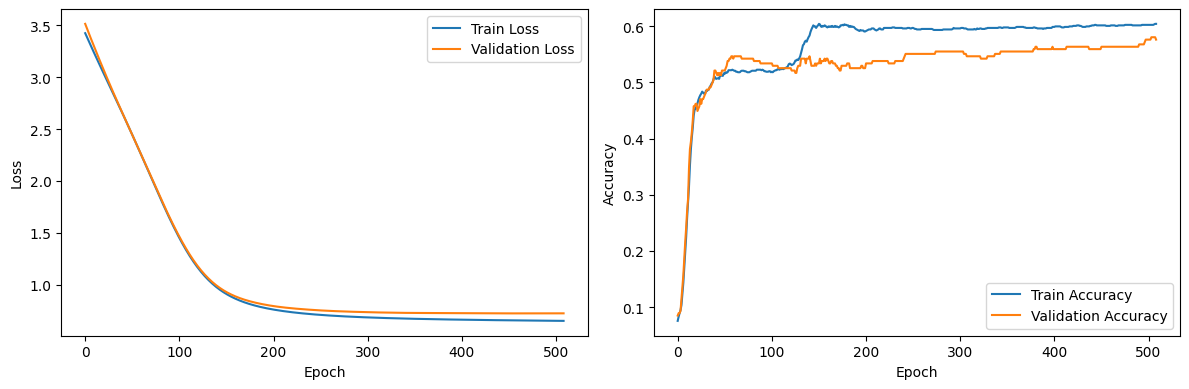


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4227, Val Loss: 3.4619, Train Acc: 0.1191, Val Acc: 0.1101
Epoch: 020, Train Loss: 3.2266, Val Loss: 3.2351, Train Acc: 0.3258, Val Acc: 0.3119
Epoch: 030, Train Loss: 3.0396, Val Loss: 3.0309, Train Acc: 0.4380, Val Acc: 0.4266
Epoch: 040, Train Loss: 2.8610, Val Loss: 2.8420, Train Acc: 0.4951, Val Acc: 0.4771
Epoch: 050, Train Loss: 2.6812, Val Loss: 2.6541, Train Acc: 0.5187, Val Acc: 0.4954
Epoch: 060, Train Loss: 2.4921, Val Loss: 2.4593, Train Acc: 0.5354, Val Acc: 0.4908
Epoch: 070, Train Loss: 2.2928, Val Loss: 2.2577, Train Acc: 0.5453, Val Acc: 0.5000
Epoch: 080, Train Loss: 2.0870, Val Loss: 2.0533, Train Acc: 0.5463, Val Acc: 0.5046
Epoch: 090, Train Loss: 1.8816, Val Loss: 1.8523, Train Acc: 0.5423, Val Acc: 0.4908
Epoch: 100, Train Loss: 1.6851, Val Loss: 1.6626, Train Acc: 0.5512, Val Acc: 0.4817
Epoch: 110, Train Loss: 1.5052, Val Loss: 1.4905, Tr

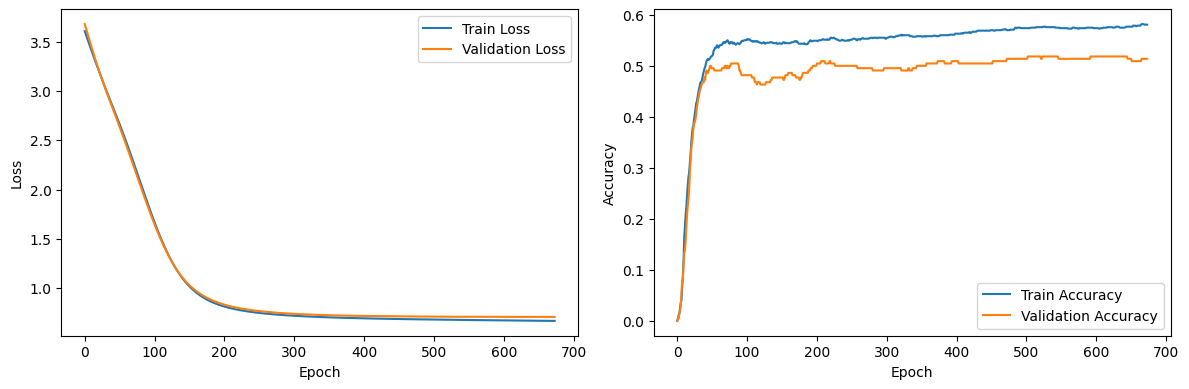


========== Run 10 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3613, Val Loss: 3.4041, Train Acc: 0.0492, Val Acc: 0.0451
Epoch: 020, Train Loss: 3.1636, Val Loss: 3.1690, Train Acc: 0.2635, Val Acc: 0.2895
Epoch: 030, Train Loss: 2.9790, Val Loss: 2.9566, Train Acc: 0.4440, Val Acc: 0.4398
Epoch: 040, Train Loss: 2.7963, Val Loss: 2.7617, Train Acc: 0.4972, Val Acc: 0.4925
Epoch: 050, Train Loss: 2.6089, Val Loss: 2.5722, Train Acc: 0.5286, Val Acc: 0.5451
Epoch: 060, Train Loss: 2.4159, Val Loss: 2.3819, Train Acc: 0.5544, Val Acc: 0.6090
Epoch: 070, Train Loss: 2.2166, Val Loss: 2.1864, Train Acc: 0.5673, Val Acc: 0.6203
Epoch: 080, Train Loss: 2.0119, Val Loss: 1.9851, Train Acc: 0.5753, Val Acc: 0.5865
Epoch: 090, Train Loss: 1.8062, Val Loss: 1.7835, Train Acc: 0.5794, Val Acc: 0.5789
Epoch: 100, Train Loss: 1.6067, Val Loss: 1.5883, Train Acc: 0.5770, Val Acc: 0.5789
Epoch: 110, Train Los

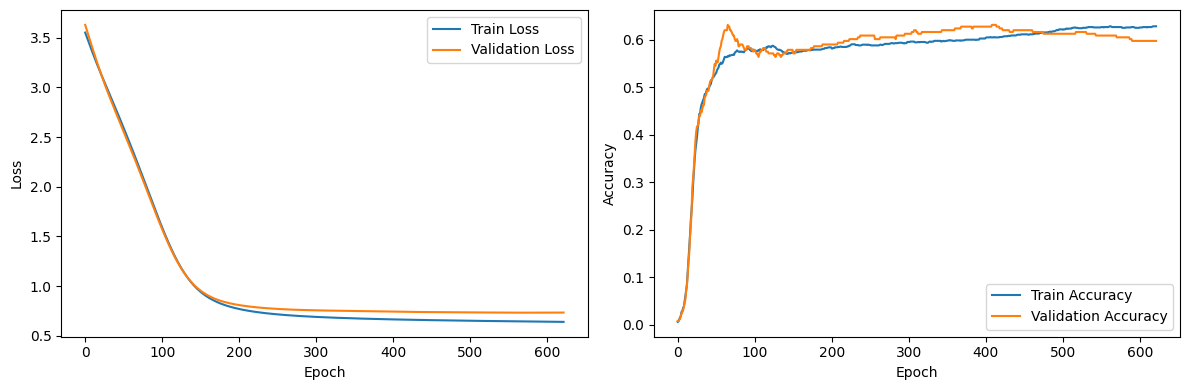


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3241, Val Loss: 3.3239, Train Acc: 0.0931, Val Acc: 0.1333
Epoch: 020, Train Loss: 3.1203, Val Loss: 3.1560, Train Acc: 0.4488, Val Acc: 0.4510
Epoch: 030, Train Loss: 2.9299, Val Loss: 2.9886, Train Acc: 0.5470, Val Acc: 0.5412
Epoch: 040, Train Loss: 2.7455, Val Loss: 2.8167, Train Acc: 0.5503, Val Acc: 0.5490
Epoch: 050, Train Loss: 2.5619, Val Loss: 2.6372, Train Acc: 0.5621, Val Acc: 0.5451
Epoch: 060, Train Loss: 2.3747, Val Loss: 2.4485, Train Acc: 0.5663, Val Acc: 0.5451
Epoch: 070, Train Loss: 2.1818, Val Loss: 2.2511, Train Acc: 0.5629, Val Acc: 0.5529
Epoch: 080, Train Loss: 1.9842, Val Loss: 2.0470, Train Acc: 0.5587, Val Acc: 0.5490
Epoch: 090, Train Loss: 1.7862, Val Loss: 1.8410, Train Acc: 0.5604, Val Acc: 0.5529
Epoch: 100, Train Loss: 1.5947, Val Loss: 1.6411, Train Acc: 0.5654, Val Acc: 0.5529
Epoch: 110, Train Loss: 1.4179, Val Loss: 1.4567, Tr

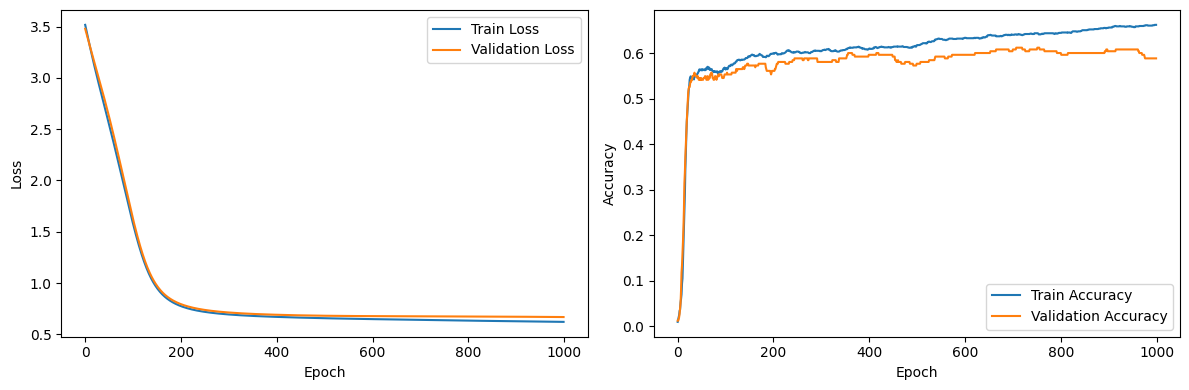


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4547, Val Loss: 3.4416, Train Acc: 0.0381, Val Acc: 0.0254
Epoch: 020, Train Loss: 3.2506, Val Loss: 3.2187, Train Acc: 0.2450, Val Acc: 0.1907
Epoch: 030, Train Loss: 3.0492, Val Loss: 3.0060, Train Acc: 0.3621, Val Acc: 0.3602
Epoch: 040, Train Loss: 2.8458, Val Loss: 2.8059, Train Acc: 0.5009, Val Acc: 0.4831
Epoch: 050, Train Loss: 2.6362, Val Loss: 2.6062, Train Acc: 0.5544, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.4190, Val Loss: 2.4001, Train Acc: 0.5662, Val Acc: 0.4915
Epoch: 070, Train Loss: 2.1956, Val Loss: 2.1881, Train Acc: 0.5753, Val Acc: 0.5000
Epoch: 080, Train Loss: 1.9707, Val Loss: 1.9741, Train Acc: 0.5789, Val Acc: 0.5042
Epoch: 090, Train Loss: 1.7519, Val Loss: 1.7653, Train Acc: 0.5708, Val Acc: 0.5042
Epoch: 100, Train Loss: 1.5490, Val Loss: 1.5713, Train Acc: 0.5708, Val Acc: 0.5000
Epoch: 110, Train Loss: 1.3711, Val Loss: 1.3998, Tr

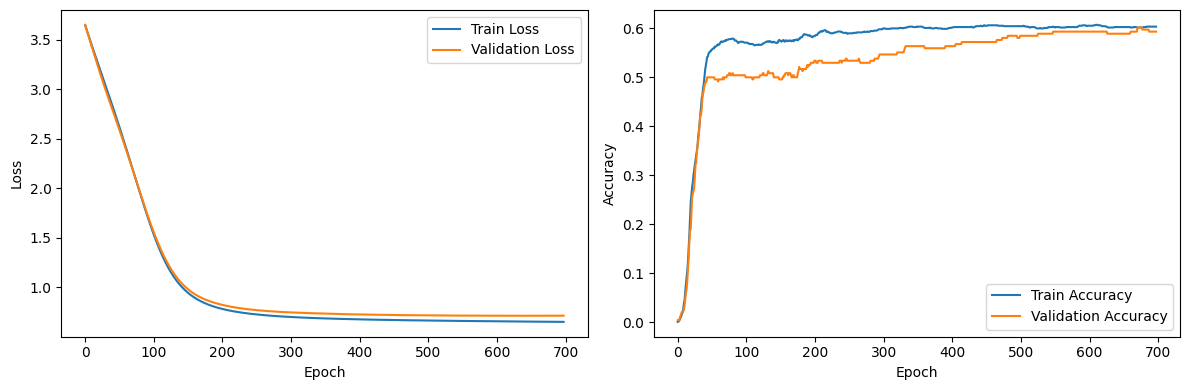


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5464, Val Loss: 3.6354, Train Acc: 0.0079, Val Acc: 0.0046
Epoch: 020, Train Loss: 3.3345, Val Loss: 3.3854, Train Acc: 0.1732, Val Acc: 0.2339
Epoch: 030, Train Loss: 3.1323, Val Loss: 3.1446, Train Acc: 0.4567, Val Acc: 0.4358
Epoch: 040, Train Loss: 2.9432, Val Loss: 2.9205, Train Acc: 0.5177, Val Acc: 0.4908
Epoch: 050, Train Loss: 2.7585, Val Loss: 2.7196, Train Acc: 0.5246, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.5727, Val Loss: 2.5252, Train Acc: 0.5315, Val Acc: 0.5000
Epoch: 070, Train Loss: 2.3810, Val Loss: 2.3283, Train Acc: 0.5236, Val Acc: 0.5138
Epoch: 080, Train Loss: 2.1821, Val Loss: 2.1274, Train Acc: 0.5187, Val Acc: 0.5092
Epoch: 090, Train Loss: 1.9788, Val Loss: 1.9271, Train Acc: 0.5256, Val Acc: 0.5092
Epoch: 100, Train Loss: 1.7771, Val Loss: 1.7326, Train Acc: 0.5236, Val Acc: 0.4954
Epoch: 110, Train Loss: 1.5855, Val Loss: 1.5514, Tr

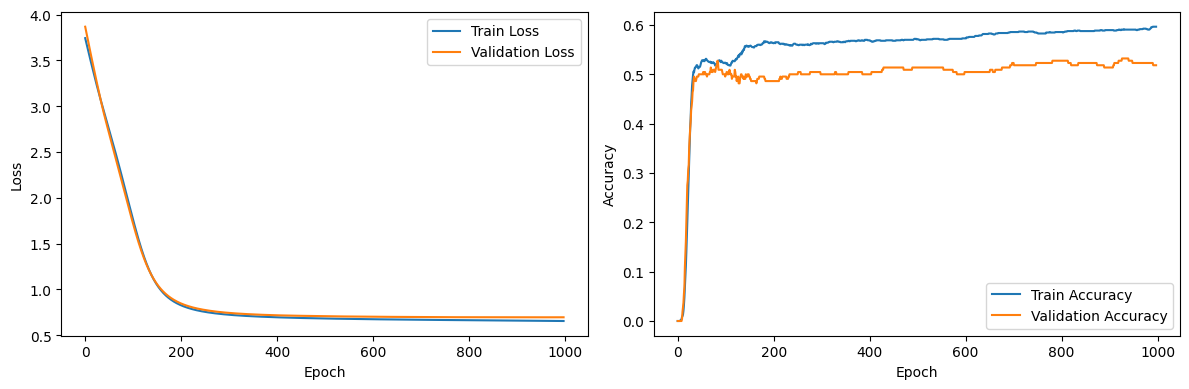


========== Run 11 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3019, Val Loss: 3.3035, Train Acc: 0.1797, Val Acc: 0.2105
Epoch: 020, Train Loss: 3.0919, Val Loss: 3.0612, Train Acc: 0.3900, Val Acc: 0.4173
Epoch: 030, Train Loss: 2.8957, Val Loss: 2.8503, Train Acc: 0.5230, Val Acc: 0.5451
Epoch: 040, Train Loss: 2.7100, Val Loss: 2.6603, Train Acc: 0.5544, Val Acc: 0.5714
Epoch: 050, Train Loss: 2.5218, Val Loss: 2.4729, Train Acc: 0.5608, Val Acc: 0.5902
Epoch: 060, Train Loss: 2.3259, Val Loss: 2.2801, Train Acc: 0.5649, Val Acc: 0.5902
Epoch: 070, Train Loss: 2.1222, Val Loss: 2.0809, Train Acc: 0.5624, Val Acc: 0.5865
Epoch: 080, Train Loss: 1.9144, Val Loss: 1.8785, Train Acc: 0.5649, Val Acc: 0.5789
Epoch: 090, Train Loss: 1.7093, Val Loss: 1.6789, Train Acc: 0.5689, Val Acc: 0.5865
Epoch: 100, Train Loss: 1.5157, Val Loss: 1.4914, Train Acc: 0.5657, Val Acc: 0.5827
Epoch: 110, Train Los

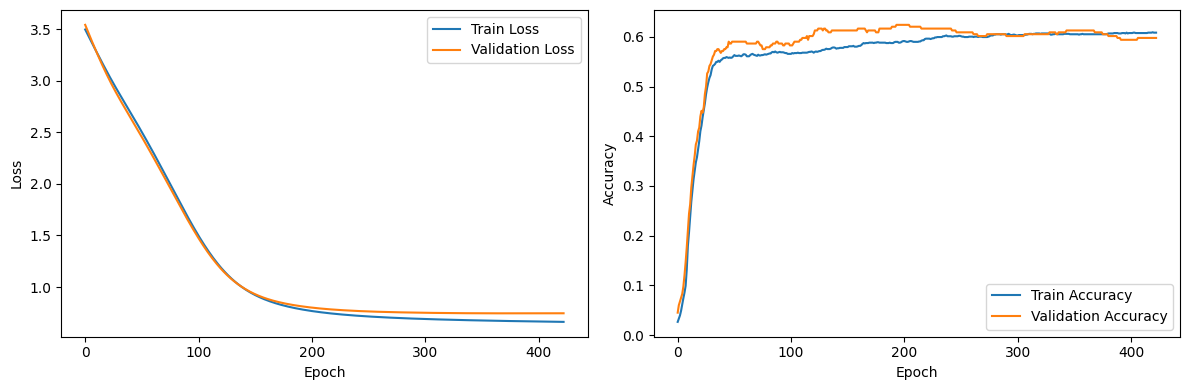


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4087, Val Loss: 3.3659, Train Acc: 0.0831, Val Acc: 0.1020
Epoch: 020, Train Loss: 3.1873, Val Loss: 3.1843, Train Acc: 0.3658, Val Acc: 0.4235
Epoch: 030, Train Loss: 2.9769, Val Loss: 3.0044, Train Acc: 0.5017, Val Acc: 0.5216
Epoch: 040, Train Loss: 2.7835, Val Loss: 2.8288, Train Acc: 0.5419, Val Acc: 0.5412
Epoch: 050, Train Loss: 2.6019, Val Loss: 2.6553, Train Acc: 0.5428, Val Acc: 0.5490
Epoch: 060, Train Loss: 2.4221, Val Loss: 2.4769, Train Acc: 0.5428, Val Acc: 0.5490
Epoch: 070, Train Loss: 2.2392, Val Loss: 2.2910, Train Acc: 0.5461, Val Acc: 0.5490
Epoch: 080, Train Loss: 2.0527, Val Loss: 2.0994, Train Acc: 0.5478, Val Acc: 0.5490
Epoch: 090, Train Loss: 1.8651, Val Loss: 1.9058, Train Acc: 0.5512, Val Acc: 0.5529
Epoch: 100, Train Loss: 1.6813, Val Loss: 1.7157, Train Acc: 0.5612, Val Acc: 0.5608
Epoch: 110, Train Loss: 1.5079, Val Loss: 1.5367, Tr

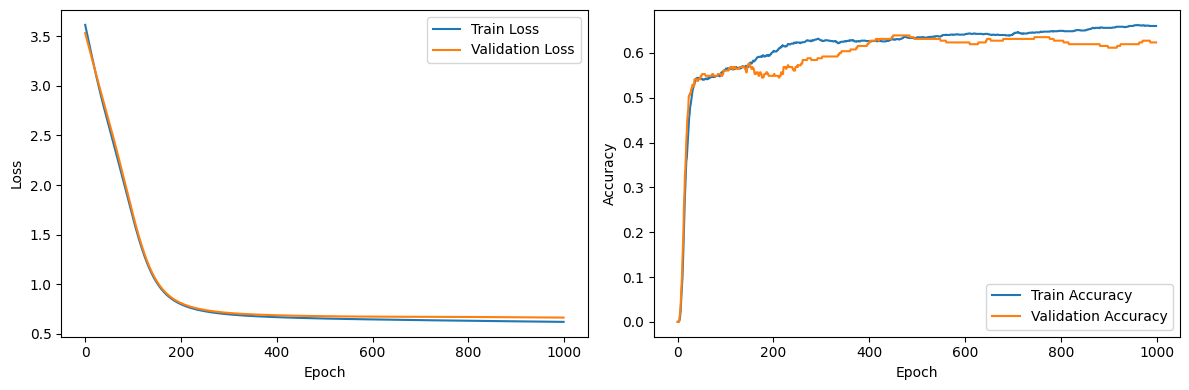


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4162, Val Loss: 3.4243, Train Acc: 0.0381, Val Acc: 0.0847
Epoch: 020, Train Loss: 3.2239, Val Loss: 3.1975, Train Acc: 0.2505, Val Acc: 0.2754
Epoch: 030, Train Loss: 3.0371, Val Loss: 2.9915, Train Acc: 0.4628, Val Acc: 0.4788
Epoch: 040, Train Loss: 2.8513, Val Loss: 2.8061, Train Acc: 0.5172, Val Acc: 0.4788
Epoch: 050, Train Loss: 2.6582, Val Loss: 2.6215, Train Acc: 0.5309, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.4548, Val Loss: 2.4288, Train Acc: 0.5481, Val Acc: 0.4831
Epoch: 070, Train Loss: 2.2415, Val Loss: 2.2259, Train Acc: 0.5563, Val Acc: 0.4958
Epoch: 080, Train Loss: 2.0220, Val Loss: 2.0154, Train Acc: 0.5690, Val Acc: 0.5042
Epoch: 090, Train Loss: 1.8028, Val Loss: 1.8045, Train Acc: 0.5662, Val Acc: 0.5169
Epoch: 100, Train Loss: 1.5939, Val Loss: 1.6026, Train Acc: 0.5672, Val Acc: 0.5085
Epoch: 110, Train Loss: 1.4057, Val Loss: 1.4203, Tr

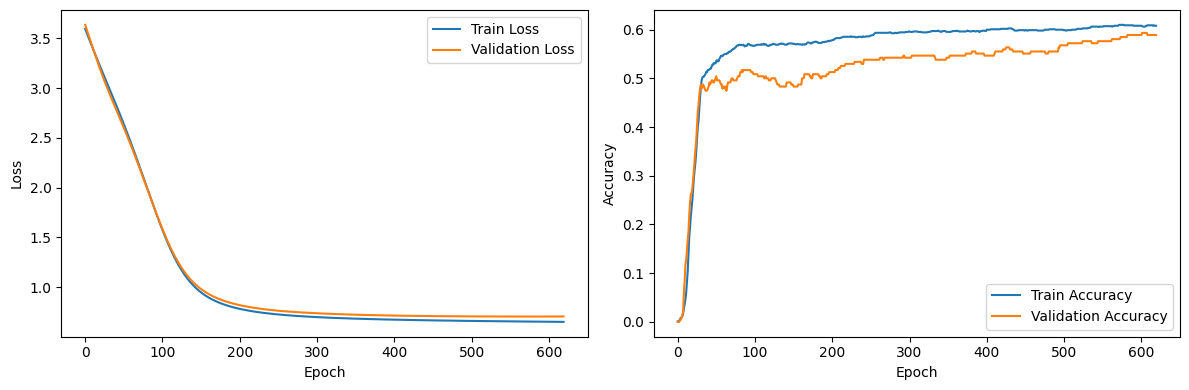


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4712, Val Loss: 3.4478, Train Acc: 0.0384, Val Acc: 0.0734
Epoch: 020, Train Loss: 3.2716, Val Loss: 3.2340, Train Acc: 0.3022, Val Acc: 0.3165
Epoch: 030, Train Loss: 3.0850, Val Loss: 3.0300, Train Acc: 0.4911, Val Acc: 0.4495
Epoch: 040, Train Loss: 2.9061, Val Loss: 2.8342, Train Acc: 0.5335, Val Acc: 0.4817
Epoch: 050, Train Loss: 2.7245, Val Loss: 2.6447, Train Acc: 0.5344, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.5366, Val Loss: 2.4570, Train Acc: 0.5394, Val Acc: 0.5092
Epoch: 070, Train Loss: 2.3415, Val Loss: 2.2674, Train Acc: 0.5423, Val Acc: 0.5183
Epoch: 080, Train Loss: 2.1408, Val Loss: 2.0757, Train Acc: 0.5433, Val Acc: 0.5229
Epoch: 090, Train Loss: 1.9384, Val Loss: 1.8840, Train Acc: 0.5453, Val Acc: 0.5138
Epoch: 100, Train Loss: 1.7406, Val Loss: 1.6975, Train Acc: 0.5423, Val Acc: 0.5138
Epoch: 110, Train Loss: 1.5554, Val Loss: 1.5238, Tr

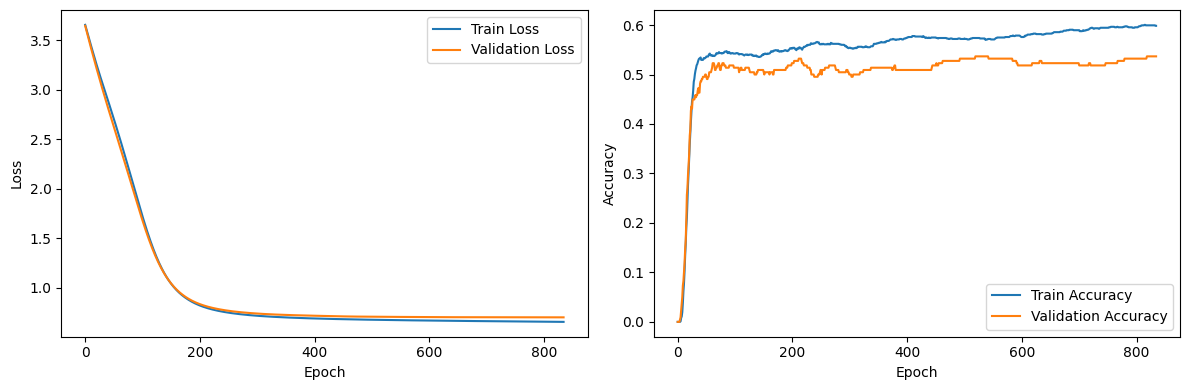


========== Run 12 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1508, Val Loss: 3.0941, Train Acc: 0.3038, Val Acc: 0.3045
Epoch: 020, Train Loss: 2.9678, Val Loss: 2.9112, Train Acc: 0.4923, Val Acc: 0.4549
Epoch: 030, Train Loss: 2.7849, Val Loss: 2.7386, Train Acc: 0.5052, Val Acc: 0.4774
Epoch: 040, Train Loss: 2.5981, Val Loss: 2.5636, Train Acc: 0.5246, Val Acc: 0.4925
Epoch: 050, Train Loss: 2.4050, Val Loss: 2.3805, Train Acc: 0.5302, Val Acc: 0.5113
Epoch: 060, Train Loss: 2.2030, Val Loss: 2.1869, Train Acc: 0.5447, Val Acc: 0.5263
Epoch: 070, Train Loss: 1.9940, Val Loss: 1.9849, Train Acc: 0.5649, Val Acc: 0.5564
Epoch: 080, Train Loss: 1.7830, Val Loss: 1.7808, Train Acc: 0.5842, Val Acc: 0.5940
Epoch: 090, Train Loss: 1.5777, Val Loss: 1.5823, Train Acc: 0.5995, Val Acc: 0.6053
Epoch: 100, Train Loss: 1.3884, Val Loss: 1.4013, Train Acc: 0.5955, Val Acc: 0.6128
Epoch: 110, Train Los

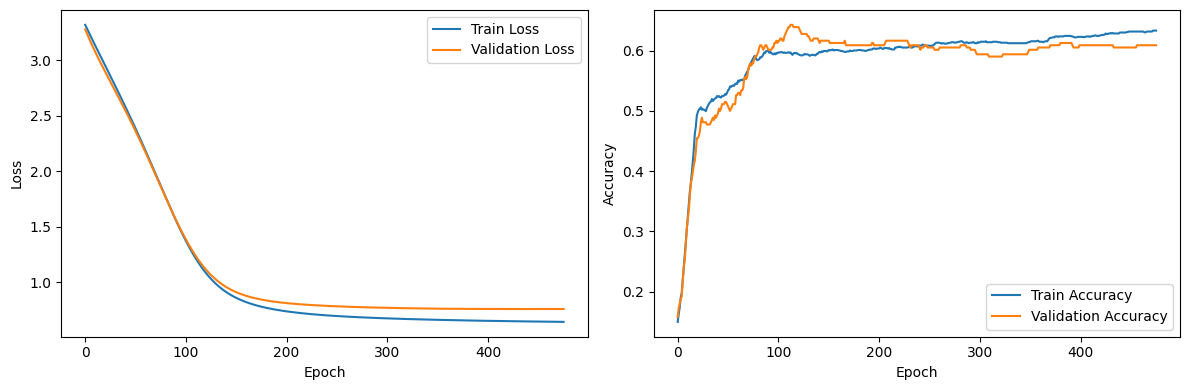


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5501, Val Loss: 3.4941, Train Acc: 0.0025, Val Acc: 0.0039
Epoch: 020, Train Loss: 3.3454, Val Loss: 3.3265, Train Acc: 0.0998, Val Acc: 0.1137
Epoch: 030, Train Loss: 3.1515, Val Loss: 3.1628, Train Acc: 0.3079, Val Acc: 0.3333
Epoch: 040, Train Loss: 2.9643, Val Loss: 2.9983, Train Acc: 0.4388, Val Acc: 0.4392
Epoch: 050, Train Loss: 2.7785, Val Loss: 2.8279, Train Acc: 0.5285, Val Acc: 0.5137
Epoch: 060, Train Loss: 2.5893, Val Loss: 2.6475, Train Acc: 0.5378, Val Acc: 0.5137
Epoch: 070, Train Loss: 2.3942, Val Loss: 2.4553, Train Acc: 0.5478, Val Acc: 0.5137
Epoch: 080, Train Loss: 2.1926, Val Loss: 2.2522, Train Acc: 0.5470, Val Acc: 0.5098
Epoch: 090, Train Loss: 1.9861, Val Loss: 2.0415, Train Acc: 0.5520, Val Acc: 0.5098
Epoch: 100, Train Loss: 1.7801, Val Loss: 1.8295, Train Acc: 0.5596, Val Acc: 0.5098
Epoch: 110, Train Loss: 1.5830, Val Loss: 1.6259, Tr

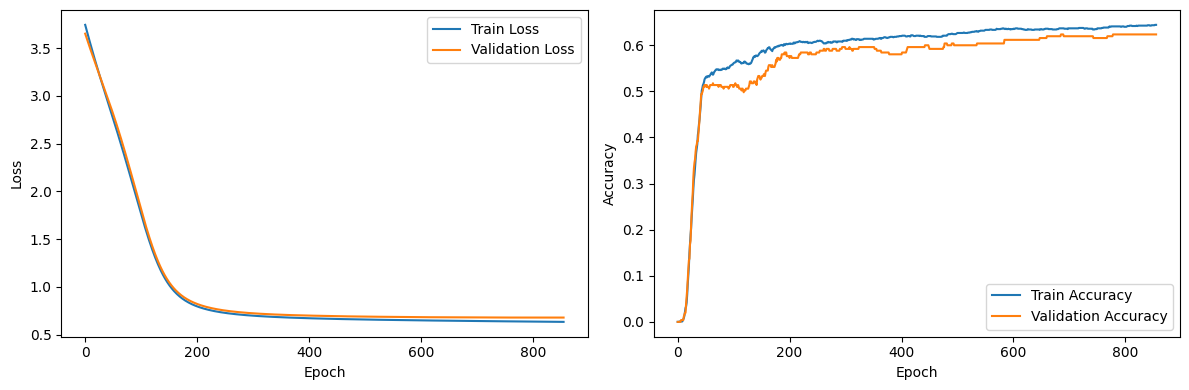


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2400, Val Loss: 3.2391, Train Acc: 0.3094, Val Acc: 0.2669
Epoch: 020, Train Loss: 3.0401, Val Loss: 3.0333, Train Acc: 0.4510, Val Acc: 0.4619
Epoch: 030, Train Loss: 2.8464, Val Loss: 2.8395, Train Acc: 0.5318, Val Acc: 0.5042
Epoch: 040, Train Loss: 2.6523, Val Loss: 2.6527, Train Acc: 0.5454, Val Acc: 0.5297
Epoch: 050, Train Loss: 2.4551, Val Loss: 2.4637, Train Acc: 0.5517, Val Acc: 0.5254
Epoch: 060, Train Loss: 2.2534, Val Loss: 2.2686, Train Acc: 0.5472, Val Acc: 0.5381
Epoch: 070, Train Loss: 2.0487, Val Loss: 2.0688, Train Acc: 0.5544, Val Acc: 0.5424
Epoch: 080, Train Loss: 1.8450, Val Loss: 1.8685, Train Acc: 0.5608, Val Acc: 0.5381
Epoch: 090, Train Loss: 1.6488, Val Loss: 1.6739, Train Acc: 0.5690, Val Acc: 0.5297
Epoch: 100, Train Loss: 1.4674, Val Loss: 1.4929, Train Acc: 0.5681, Val Acc: 0.5212
Epoch: 110, Train Loss: 1.3082, Val Loss: 1.3330, Tr

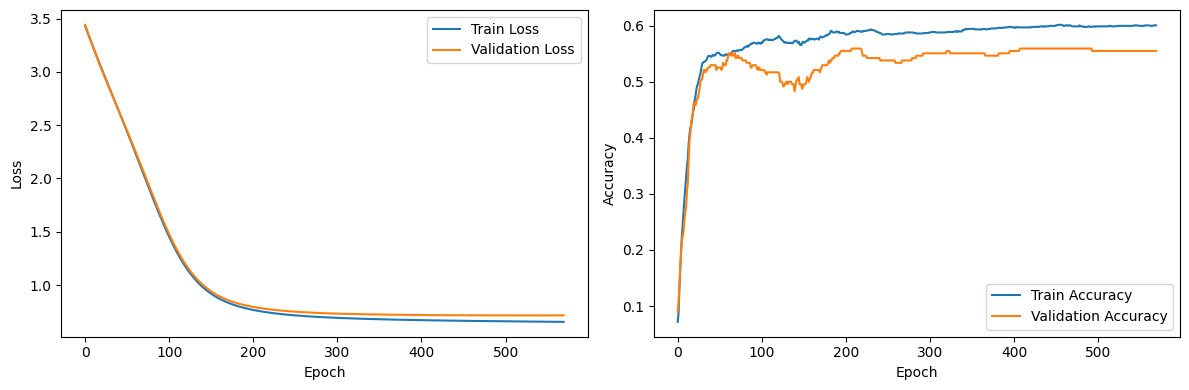


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4332, Val Loss: 3.4501, Train Acc: 0.1309, Val Acc: 0.1055
Epoch: 020, Train Loss: 3.2337, Val Loss: 3.2070, Train Acc: 0.2411, Val Acc: 0.2294
Epoch: 030, Train Loss: 3.0443, Val Loss: 2.9841, Train Acc: 0.3652, Val Acc: 0.3853
Epoch: 040, Train Loss: 2.8632, Val Loss: 2.7940, Train Acc: 0.4528, Val Acc: 0.4679
Epoch: 050, Train Loss: 2.6865, Val Loss: 2.6153, Train Acc: 0.4783, Val Acc: 0.5000
Epoch: 060, Train Loss: 2.5062, Val Loss: 2.4350, Train Acc: 0.4783, Val Acc: 0.5000
Epoch: 070, Train Loss: 2.3188, Val Loss: 2.2503, Train Acc: 0.4803, Val Acc: 0.4908
Epoch: 080, Train Loss: 2.1249, Val Loss: 2.0620, Train Acc: 0.4764, Val Acc: 0.4908
Epoch: 090, Train Loss: 1.9281, Val Loss: 1.8733, Train Acc: 0.4783, Val Acc: 0.5092
Epoch: 100, Train Loss: 1.7347, Val Loss: 1.6901, Train Acc: 0.4872, Val Acc: 0.4817
Epoch: 110, Train Loss: 1.5518, Val Loss: 1.5186, Tr

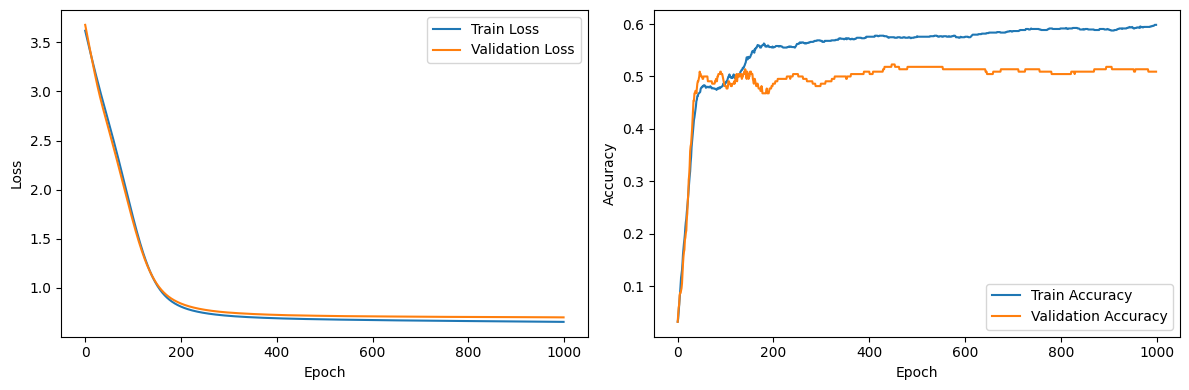


========== Run 13 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3496, Val Loss: 3.3222, Train Acc: 0.0830, Val Acc: 0.1203
Epoch: 020, Train Loss: 3.1344, Val Loss: 3.0839, Train Acc: 0.4142, Val Acc: 0.5075
Epoch: 030, Train Loss: 2.9276, Val Loss: 2.8673, Train Acc: 0.5504, Val Acc: 0.5902
Epoch: 040, Train Loss: 2.7270, Val Loss: 2.6645, Train Acc: 0.5745, Val Acc: 0.6128
Epoch: 050, Train Loss: 2.5262, Val Loss: 2.4670, Train Acc: 0.5850, Val Acc: 0.6090
Epoch: 060, Train Loss: 2.3225, Val Loss: 2.2691, Train Acc: 0.5842, Val Acc: 0.6090
Epoch: 070, Train Loss: 2.1151, Val Loss: 2.0696, Train Acc: 0.5898, Val Acc: 0.6128
Epoch: 080, Train Loss: 1.9075, Val Loss: 1.8694, Train Acc: 0.5963, Val Acc: 0.6015
Epoch: 090, Train Loss: 1.7060, Val Loss: 1.6749, Train Acc: 0.5947, Val Acc: 0.5977
Epoch: 100, Train Loss: 1.5183, Val Loss: 1.4944, Train Acc: 0.5939, Val Acc: 0.6015
Epoch: 110, Train Los

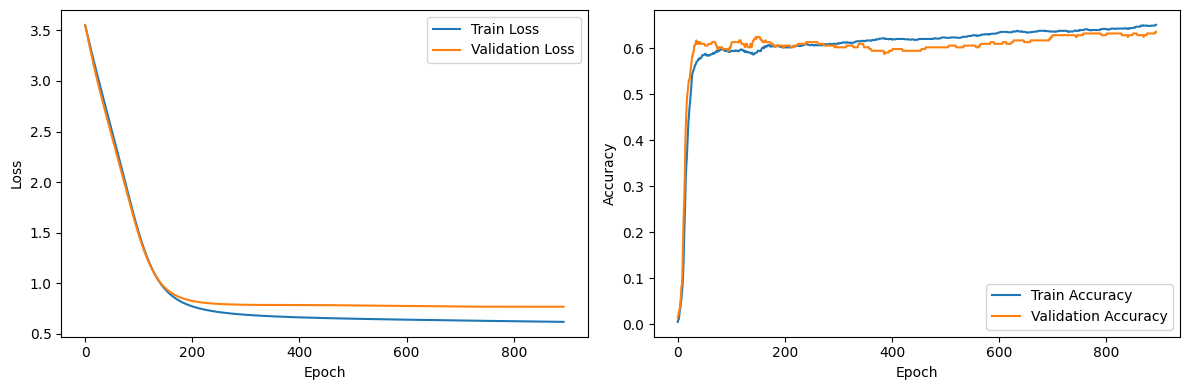


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2628, Val Loss: 3.2825, Train Acc: 0.1477, Val Acc: 0.1373
Epoch: 020, Train Loss: 3.0626, Val Loss: 3.1052, Train Acc: 0.3490, Val Acc: 0.3412
Epoch: 030, Train Loss: 2.8721, Val Loss: 2.9292, Train Acc: 0.5201, Val Acc: 0.4824
Epoch: 040, Train Loss: 2.6856, Val Loss: 2.7506, Train Acc: 0.5260, Val Acc: 0.5020
Epoch: 050, Train Loss: 2.4959, Val Loss: 2.5635, Train Acc: 0.5302, Val Acc: 0.4863
Epoch: 060, Train Loss: 2.2997, Val Loss: 2.3660, Train Acc: 0.5394, Val Acc: 0.5059
Epoch: 070, Train Loss: 2.0977, Val Loss: 2.1597, Train Acc: 0.5629, Val Acc: 0.5216
Epoch: 080, Train Loss: 1.8927, Val Loss: 1.9485, Train Acc: 0.5663, Val Acc: 0.5098
Epoch: 090, Train Loss: 1.6904, Val Loss: 1.7395, Train Acc: 0.5713, Val Acc: 0.5216
Epoch: 100, Train Loss: 1.4994, Val Loss: 1.5422, Train Acc: 0.5721, Val Acc: 0.5137
Epoch: 110, Train Loss: 1.3290, Val Loss: 1.3662, Tr

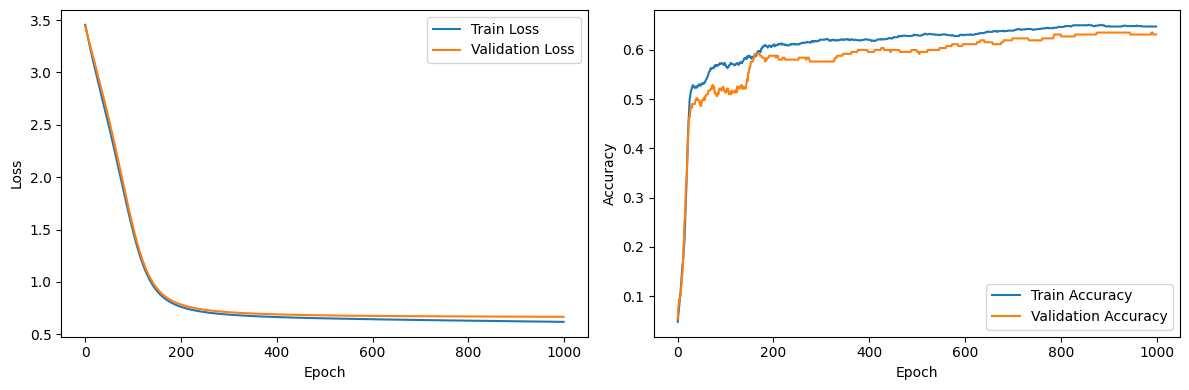


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2363, Val Loss: 3.2759, Train Acc: 0.3521, Val Acc: 0.3602
Epoch: 020, Train Loss: 3.0574, Val Loss: 3.0744, Train Acc: 0.4682, Val Acc: 0.4619
Epoch: 030, Train Loss: 2.8828, Val Loss: 2.8925, Train Acc: 0.4855, Val Acc: 0.4703
Epoch: 040, Train Loss: 2.7074, Val Loss: 2.7175, Train Acc: 0.5000, Val Acc: 0.4661
Epoch: 050, Train Loss: 2.5259, Val Loss: 2.5408, Train Acc: 0.5045, Val Acc: 0.4661
Epoch: 060, Train Loss: 2.3364, Val Loss: 2.3577, Train Acc: 0.5073, Val Acc: 0.4661
Epoch: 070, Train Loss: 2.1398, Val Loss: 2.1659, Train Acc: 0.5045, Val Acc: 0.4703
Epoch: 080, Train Loss: 1.9397, Val Loss: 1.9688, Train Acc: 0.5082, Val Acc: 0.4788
Epoch: 090, Train Loss: 1.7421, Val Loss: 1.7729, Train Acc: 0.5064, Val Acc: 0.4873
Epoch: 100, Train Loss: 1.5552, Val Loss: 1.5859, Train Acc: 0.5073, Val Acc: 0.4873
Epoch: 110, Train Loss: 1.3865, Val Loss: 1.4166, Tr

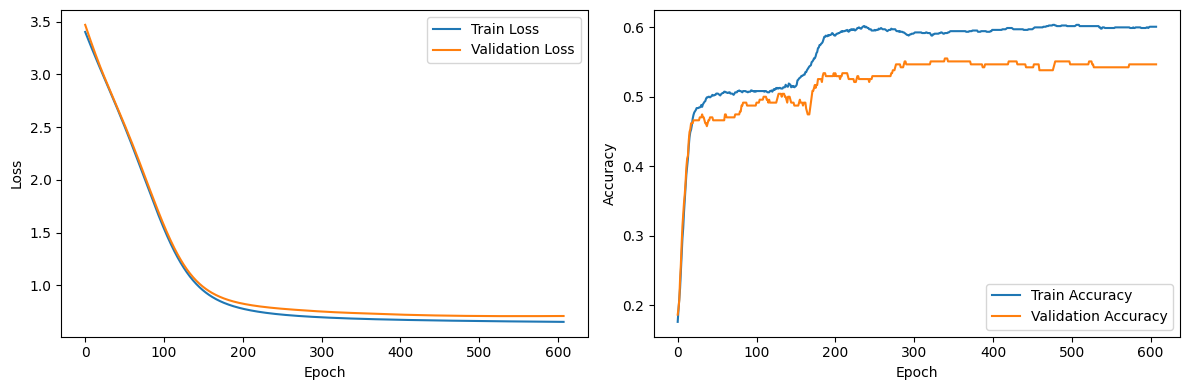


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4368, Val Loss: 3.4436, Train Acc: 0.1683, Val Acc: 0.1606
Epoch: 020, Train Loss: 3.2426, Val Loss: 3.2296, Train Acc: 0.3612, Val Acc: 0.3578
Epoch: 030, Train Loss: 3.0586, Val Loss: 3.0314, Train Acc: 0.4862, Val Acc: 0.4679
Epoch: 040, Train Loss: 2.8833, Val Loss: 2.8513, Train Acc: 0.5217, Val Acc: 0.4908
Epoch: 050, Train Loss: 2.7084, Val Loss: 2.6772, Train Acc: 0.5394, Val Acc: 0.5092
Epoch: 060, Train Loss: 2.5295, Val Loss: 2.4993, Train Acc: 0.5463, Val Acc: 0.5046
Epoch: 070, Train Loss: 2.3432, Val Loss: 2.3138, Train Acc: 0.5472, Val Acc: 0.5092
Epoch: 080, Train Loss: 2.1500, Val Loss: 2.1224, Train Acc: 0.5472, Val Acc: 0.5138
Epoch: 090, Train Loss: 1.9531, Val Loss: 1.9289, Train Acc: 0.5482, Val Acc: 0.5092
Epoch: 100, Train Loss: 1.7581, Val Loss: 1.7398, Train Acc: 0.5463, Val Acc: 0.5092
Epoch: 110, Train Loss: 1.5730, Val Loss: 1.5623, Tr

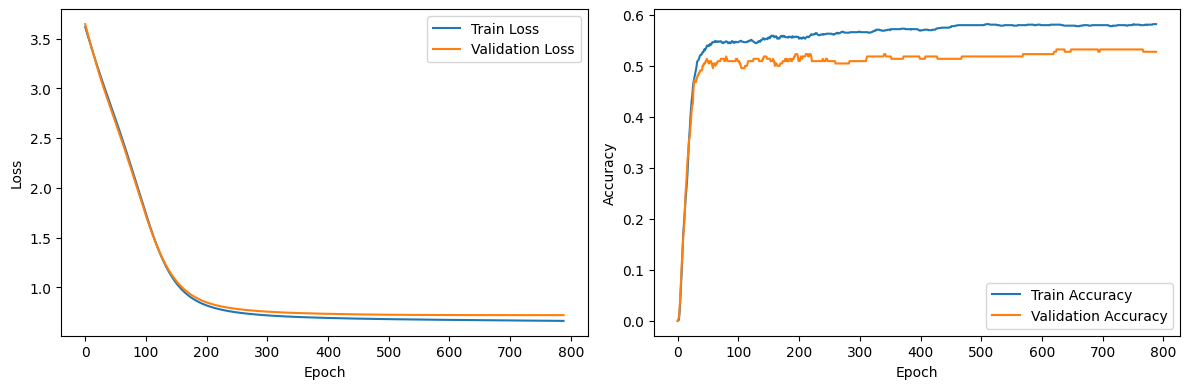


========== Run 14 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3126, Val Loss: 3.2873, Train Acc: 0.0153, Val Acc: 0.0263
Epoch: 020, Train Loss: 3.1227, Val Loss: 3.0656, Train Acc: 0.3691, Val Acc: 0.4211
Epoch: 030, Train Loss: 2.9358, Val Loss: 2.8611, Train Acc: 0.5367, Val Acc: 0.5639
Epoch: 040, Train Loss: 2.7444, Val Loss: 2.6646, Train Acc: 0.5745, Val Acc: 0.5977
Epoch: 050, Train Loss: 2.5446, Val Loss: 2.4648, Train Acc: 0.5786, Val Acc: 0.5940
Epoch: 060, Train Loss: 2.3349, Val Loss: 2.2597, Train Acc: 0.5802, Val Acc: 0.5865
Epoch: 070, Train Loss: 2.1174, Val Loss: 2.0508, Train Acc: 0.5826, Val Acc: 0.6015
Epoch: 080, Train Loss: 1.8972, Val Loss: 1.8420, Train Acc: 0.5794, Val Acc: 0.5977
Epoch: 090, Train Loss: 1.6828, Val Loss: 1.6408, Train Acc: 0.5786, Val Acc: 0.5714
Epoch: 100, Train Loss: 1.4847, Val Loss: 1.4571, Train Acc: 0.5794, Val Acc: 0.5714
Epoch: 110, Train Los

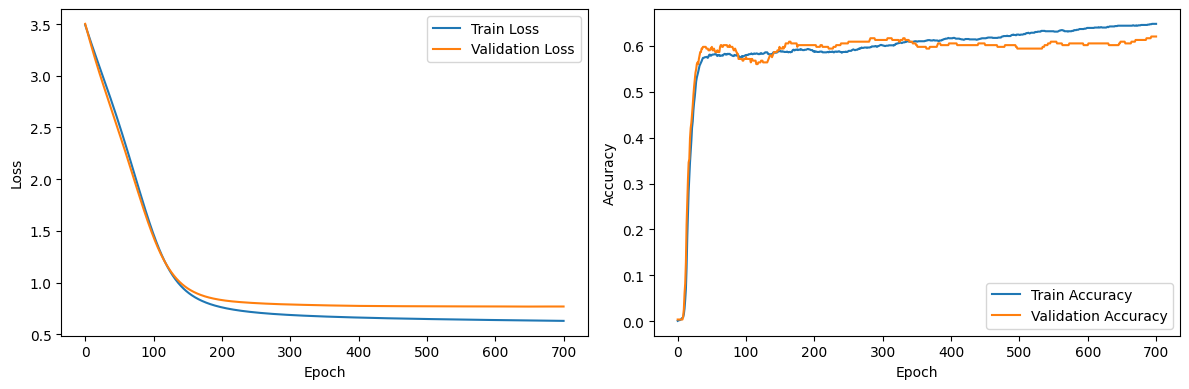


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4501, Val Loss: 3.3968, Train Acc: 0.0302, Val Acc: 0.0863
Epoch: 020, Train Loss: 3.2306, Val Loss: 3.2211, Train Acc: 0.3624, Val Acc: 0.4039
Epoch: 030, Train Loss: 3.0245, Val Loss: 3.0504, Train Acc: 0.4992, Val Acc: 0.5176
Epoch: 040, Train Loss: 2.8326, Val Loss: 2.8805, Train Acc: 0.5503, Val Acc: 0.5647
Epoch: 050, Train Loss: 2.6496, Val Loss: 2.7065, Train Acc: 0.5520, Val Acc: 0.5647
Epoch: 060, Train Loss: 2.4658, Val Loss: 2.5247, Train Acc: 0.5596, Val Acc: 0.5647
Epoch: 070, Train Loss: 2.2775, Val Loss: 2.3344, Train Acc: 0.5646, Val Acc: 0.5686
Epoch: 080, Train Loss: 2.0843, Val Loss: 2.1368, Train Acc: 0.5680, Val Acc: 0.5686
Epoch: 090, Train Loss: 1.8888, Val Loss: 1.9351, Train Acc: 0.5721, Val Acc: 0.5686
Epoch: 100, Train Loss: 1.6959, Val Loss: 1.7357, Train Acc: 0.5772, Val Acc: 0.5686
Epoch: 110, Train Loss: 1.5130, Val Loss: 1.5464, Tr

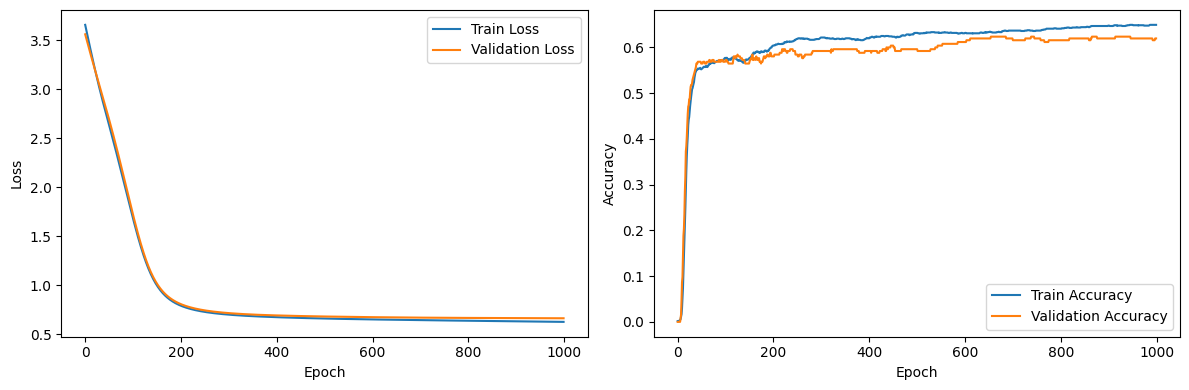


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3332, Val Loss: 3.3895, Train Acc: 0.1089, Val Acc: 0.1314
Epoch: 020, Train Loss: 3.1427, Val Loss: 3.1694, Train Acc: 0.4328, Val Acc: 0.4746
Epoch: 030, Train Loss: 2.9573, Val Loss: 2.9610, Train Acc: 0.4800, Val Acc: 0.5127
Epoch: 040, Train Loss: 2.7703, Val Loss: 2.7639, Train Acc: 0.4909, Val Acc: 0.5381
Epoch: 050, Train Loss: 2.5764, Val Loss: 2.5734, Train Acc: 0.5000, Val Acc: 0.5381
Epoch: 060, Train Loss: 2.3742, Val Loss: 2.3798, Train Acc: 0.5045, Val Acc: 0.5127
Epoch: 070, Train Loss: 2.1648, Val Loss: 2.1798, Train Acc: 0.5054, Val Acc: 0.5127
Epoch: 080, Train Loss: 1.9519, Val Loss: 1.9758, Train Acc: 0.5100, Val Acc: 0.5254
Epoch: 090, Train Loss: 1.7427, Val Loss: 1.7745, Train Acc: 0.5118, Val Acc: 0.5254
Epoch: 100, Train Loss: 1.5461, Val Loss: 1.5839, Train Acc: 0.5181, Val Acc: 0.5339
Epoch: 110, Train Loss: 1.3712, Val Loss: 1.4133, Tr

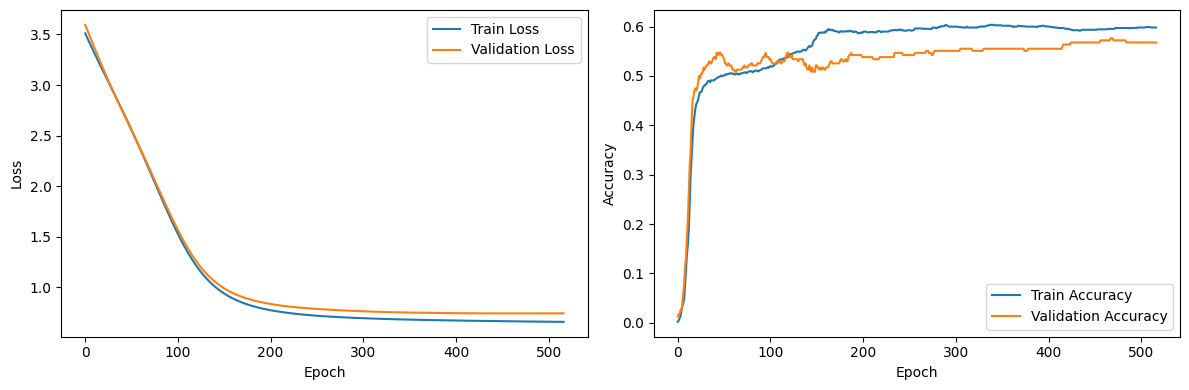


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3458, Val Loss: 3.3274, Train Acc: 0.0984, Val Acc: 0.1239
Epoch: 020, Train Loss: 3.1456, Val Loss: 3.1198, Train Acc: 0.4518, Val Acc: 0.4174
Epoch: 030, Train Loss: 2.9623, Val Loss: 2.9329, Train Acc: 0.5384, Val Acc: 0.4771
Epoch: 040, Train Loss: 2.7869, Val Loss: 2.7554, Train Acc: 0.5492, Val Acc: 0.4954
Epoch: 050, Train Loss: 2.6094, Val Loss: 2.5791, Train Acc: 0.5453, Val Acc: 0.4954
Epoch: 060, Train Loss: 2.4256, Val Loss: 2.3988, Train Acc: 0.5413, Val Acc: 0.4954
Epoch: 070, Train Loss: 2.2350, Val Loss: 2.2134, Train Acc: 0.5404, Val Acc: 0.4862
Epoch: 080, Train Loss: 2.0399, Val Loss: 2.0246, Train Acc: 0.5364, Val Acc: 0.5000
Epoch: 090, Train Loss: 1.8455, Val Loss: 1.8369, Train Acc: 0.5384, Val Acc: 0.4862
Epoch: 100, Train Loss: 1.6580, Val Loss: 1.6562, Train Acc: 0.5453, Val Acc: 0.4954
Epoch: 110, Train Loss: 1.4848, Val Loss: 1.4888, Tr

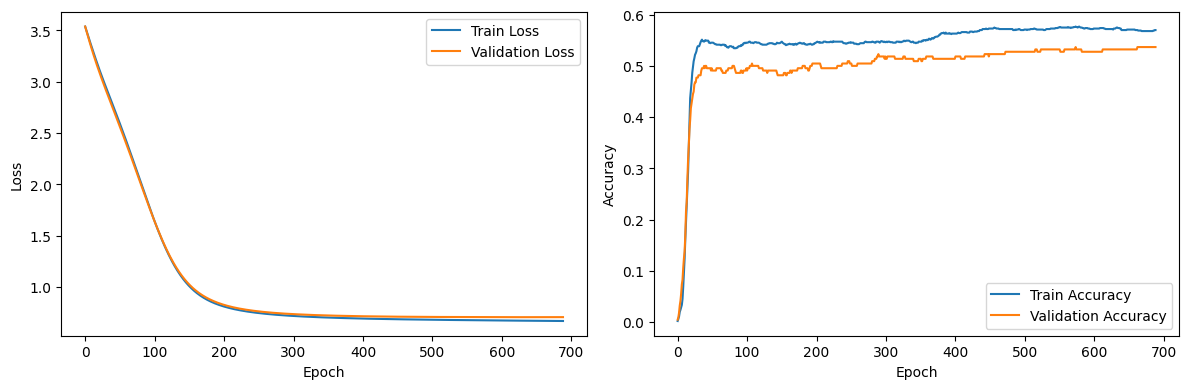


========== Final Summary ==========

Year: 2019
  Avg Test Accuracy: 0.6150 ± 0.0105
  Avg Test F1 Score: 0.6148 ± 0.0106
 Train Accuracy: 0.6304 ± 0.0173
Year: 2020
  Avg Test Accuracy: 0.5737 ± 0.0122
  Avg Test F1 Score: 0.5735 ± 0.0122
 Train Accuracy: 0.6503 ± 0.0064
Year: 2021
  Avg Test Accuracy: 0.5374 ± 0.0084
  Avg Test F1 Score: 0.5370 ± 0.0082
 Train Accuracy: 0.6044 ± 0.0049
Year: 2022
  Avg Test Accuracy: 0.5560 ± 0.0140
  Avg Test F1 Score: 0.5549 ± 0.0142
 Train Accuracy: 0.5875 ± 0.0100


In [6]:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022]
    metric = 'revenue'

    # To store results for each year across 10 runs
    aggregate_results = {year: {'acc': [], 'f1': [], 'time': [], 'epochs': [], 'best_train_acc': []} for year in years}
    param = {
            "hidden_channels": 64,
            "out_channels": 32,
            "num_heads": 4,
            "lr": 0.0009,
            "weight_decay": 5e-4,
            "epochs": 1000,
            "patience": 50
        }

    #Add optuna code section here
    best_params_per_year = {}
    # for year in years:
    #     print(f"\nRunning Optuna optimization for year {year}...\n")
    
    #     study = optuna.create_study(direction="maximize")
    #     study.optimize(lambda trial: objective(trial, year, metric), n_trials=15)
    
    #     print(f"Best trial for year {year}: {study.best_trial.value}")
    #     print("Best hyperparameters:", study.best_params)

    #     best_params_per_year[year] = study.best_params
    
    for i in range(1, 15):
        print(f"\n========== Run {i} ==========\n")
        for year in years:
            # param = best_params_per_year[year]
            print(f"\nRunning experiment for year {year}...\n")
            results = run_experiment(year, metric, **param)
            # Store individual run metrics
            aggregate_results[year]['acc'].append(results['test_acc'])
            aggregate_results[year]['f1'].append(results['test_f1'])
            aggregate_results[year]['time'].append(results['training_time'])
            aggregate_results[year]['epochs'].append(results['epochs_run'])
            aggregate_results[year]['best_train_acc'].append(results['best_train_acc'])

    print("\n========== Final Summary ==========\n")
    for year in years:
        acc_mean = np.mean(aggregate_results[year]['acc'])
        acc_std = np.std(aggregate_results[year]['acc'])
        f1_mean = np.mean(aggregate_results[year]['f1'])
        f1_std = np.std(aggregate_results[year]['f1'])
        train_acc_mean = np.mean(aggregate_results[year]['best_train_acc'])
        train_acc_std = np.std(aggregate_results[year]['best_train_acc'])

        print(f"Year: {year}")
        print(f"  Avg Test Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
        print(f"  Avg Test F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f" Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")